# 0. 라이브러리 세팅

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')
import os

In [4]:
# 맷플롯립 한글 설정 
# matplotlib Korean font
plt.rc('font', family='Malgun Gothic')

In [5]:
# 모든 컬럼을 표시하도록 설정
pd.set_option('display.max_columns', None)

# 컬럼의 너비 제한 해제
pd.set_option('display.max_colwidth', None)

# 출력할 행의 수를 설정 (필요에 따라 조정)
pd.set_option('display.max_rows', 100)


# 1. 행정구역 경계 시각화

In [9]:
# 행정구역 경계 데이터 경로
data_path_emd = "00data/세종특별자치시/36000/TL_SCCO_EMD.shp"
data_path_li = "00data/세종특별자치시/36000/TL_SCCO_LI.shp"
data_path_build = "00data/세종특별자치시/36000/TL_SPBD_BULD.shp"
data_path_rw = "00data/세종특별자치시/36000/TL_SPRD_RW.shp"

# Shapefile 데이터 불러오기
adm_emd = gpd.read_file(data_path_emd, encoding='euc-kr')
adm_li = gpd.read_file(data_path_li, encoding='euc-kr')
building = gpd.read_file(data_path_build, encoding='euc-kr')
rw_poly = gpd.read_file(data_path_rw, encoding='euc-kr')

In [10]:
# 좌표계 설정
adm_emd = adm_emd.set_crs('EPSG:5179')
adm_li = adm_li.set_crs('EPSG:5179')
building = building.set_crs('EPSG:5179')
rw_poly = rw_poly.set_crs('EPSG:5179')

adm_emd_4326 = adm_emd.to_crs(epsg=4326)
adm_li_4326 = adm_li.to_crs(epsg=4326)
building_4326 = building.to_crs(epsg=4326)
rw_poly_4326 = rw_poly.to_crs(epsg=4326)

# 좌표계 확인
print(adm_emd_4326.crs)
print(adm_li_4326.crs)
print(building_4326.crs)
print(rw_poly_4326.crs)

EPSG:4326
EPSG:4326
EPSG:4326
EPSG:4326


In [15]:
# 대상지 경계 파일 불러오기
sejong_zone_adm = gpd.read_file('00data/11.세종시_대상구역도.geojson').copy()
sejong_zone_adm_boundary = sejong_zone_adm.boundary

<Axes: >

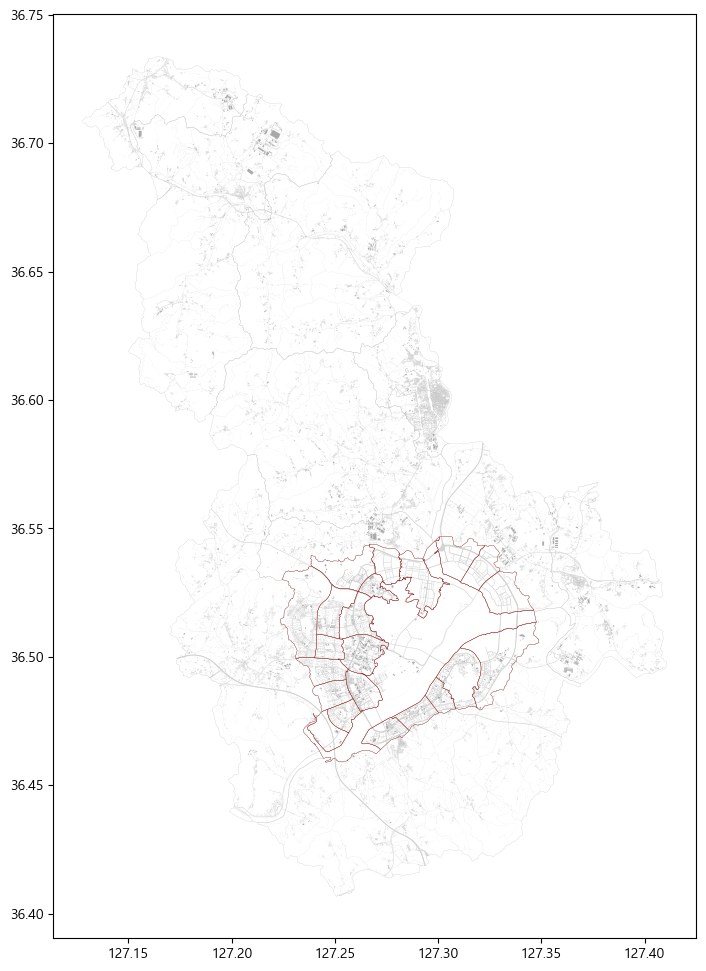

In [16]:
# ax 객체 생성
fig, ax = plt.subplots(figsize=(12, 12))

# 도로 데이터
rw_poly_4326.plot(ax=ax, facecolor='lightgrey', zorder=1) # 요놈이 다 색칠
# 건물 데이터
building_4326.plot(ax=ax, facecolor='darkgrey', zorder=2)

# 각 레이어 스타일 설정
adm_li_4326.plot(ax=ax, edgecolor='lightgrey', facecolor='none', linewidth=0.05, zorder=3)
adm_emd_4326.plot(ax=ax, edgecolor='darkgrey', facecolor='none', linewidth=0.1, zorder=4)

# 세종시 경계
sejong_zone_adm_boundary.plot(ax=ax, facecolor='none', edgecolor='DarkRed', linewidth=0.2, zorder=7)


TypeError: `keep_geom_type` does not support GeometryCollection.

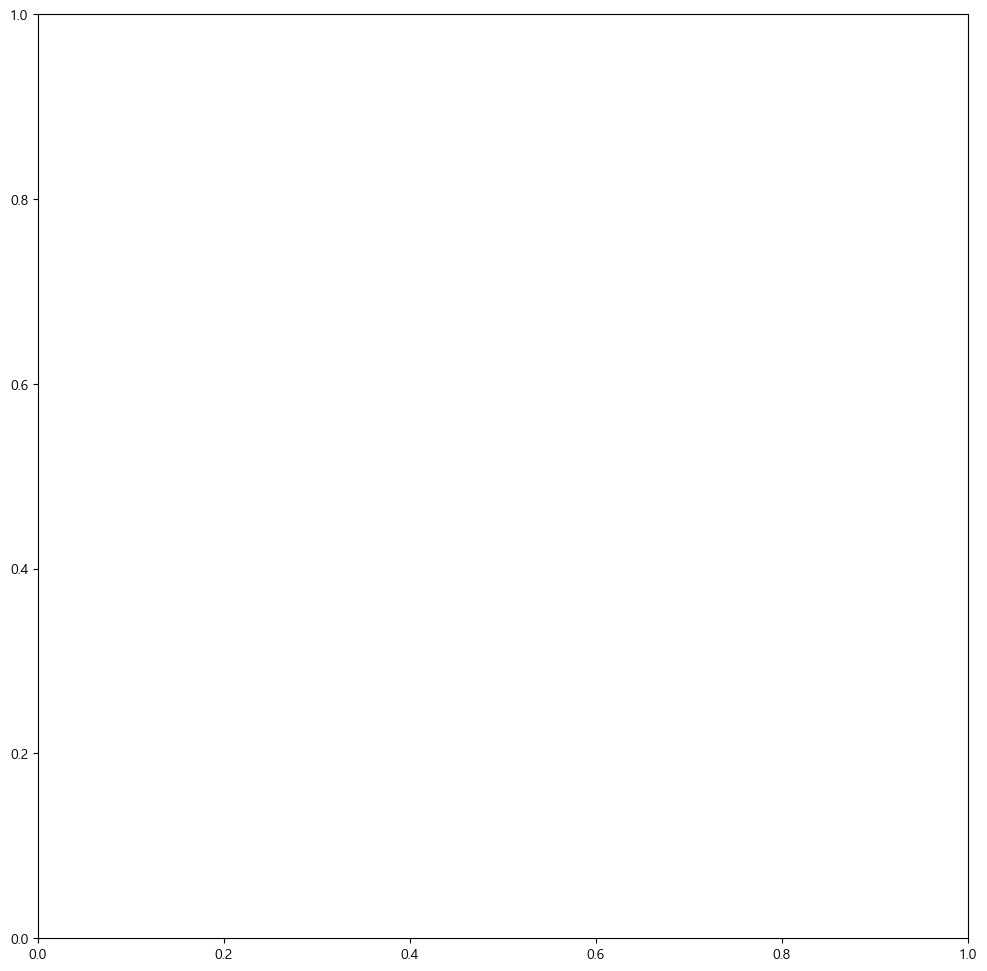

In [23]:
# ax 객체 생성
fig, ax = plt.subplots(figsize=(12, 12))

# 대상구역계 안에 있는 정보만 클리핑 및 추출
# '리(li)'단위는 대상지 밖으로 제외.
# 시군구,시도 단위 데이터는 동일한 경계 & 내부 분할 되어있지 않음.
rw_poly_clipped = gpd.clip(rw_poly_4326, sejong_zone_adm)
building_clipped = gpd.sjoin(building_4326, sejong_zone_adm, how='inner', op='within')

# 도로 데이터
rw_poly_clipped.plot(ax=ax, facecolor='lightgrey', zorder=1)
# 건물 데이터
building_clipped.plot(ax=ax, facecolor='darkgrey', zorder=2)
# 세종시 경계(기존 읍면동 단위)
sejong_zone_adm_boundary.plot(ax=ax, facecolor='none', edgecolor='DarkRed', linewidth=0.2, zorder=3)

plt.show()

## 100x100m 격자 추가

In [27]:
area_grid = gpd.read_file('00data/4.세종시_격자(매핑용).geojson').copy()

print(area_grid.head())

        gid  \
0  다바778286   
1  다바901373   
2  다바806430   
3  다바838306   
4  다바759344   

                                                                                                         geometry  
0  POLYGON ((127.25225 36.45473, 127.25225 36.45563, 127.25337 36.45563, 127.25337 36.45473, 127.25225 36.45473))  
1  POLYGON ((127.38941 36.53337, 127.38941 36.53427, 127.39052 36.53427, 127.39052 36.53337, 127.38941 36.53337))  
2  POLYGON ((127.28314 36.58461, 127.28314 36.58551, 127.28425 36.58551, 127.28426 36.58461, 127.28314 36.58461))  
3  POLYGON ((127.31917 36.47288, 127.31917 36.47378, 127.32028 36.47378, 127.32029 36.47288, 127.31917 36.47288))  
4  POLYGON ((127.23087 36.50697, 127.23087 36.50787, 127.23198 36.50788, 127.23199 36.50697, 127.23087 36.50697))  


In [28]:
# area_grid 좌표계 확인
area_grid.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [29]:
# area_grid.set_crs(epsg=4326, inplace=True)

# 겹치는 부분만 남기고 필터링
area_grid_intsc = gpd.overlay(area_grid, sejong_zone_adm, how='intersection')

# 결과 확인
print(area_grid_intsc.head())

        gid    EMD_CD COL_ADM_SE EMD_NM  \
0  다바759344  36110112      36110    고운동   
1  다바758350  36110112      36110    고운동   
2  다바769344  36110111      36110    종촌동   
3  다바833335  36110101      36110    반곡동   
4  다바759358  36110112      36110    고운동   

                                                                                                         geometry  
0  POLYGON ((127.23087 36.50787, 127.23198 36.50788, 127.23199 36.50697, 127.23087 36.50697, 127.23087 36.50787))  
1  POLYGON ((127.22973 36.51328, 127.23085 36.51328, 127.23085 36.51238, 127.22973 36.51238, 127.22973 36.51328))  
2         POLYGON ((127.24203 36.5079, 127.24315 36.5079, 127.24315 36.507, 127.24204 36.507, 127.24203 36.5079))  
3  POLYGON ((127.31352 36.49992, 127.31464 36.49992, 127.31464 36.49902, 127.31353 36.49902, 127.31352 36.49992))  
4   POLYGON ((127.23082 36.52049, 127.23194 36.5205, 127.23194 36.51959, 127.23082 36.51959, 127.23082 36.52049))  


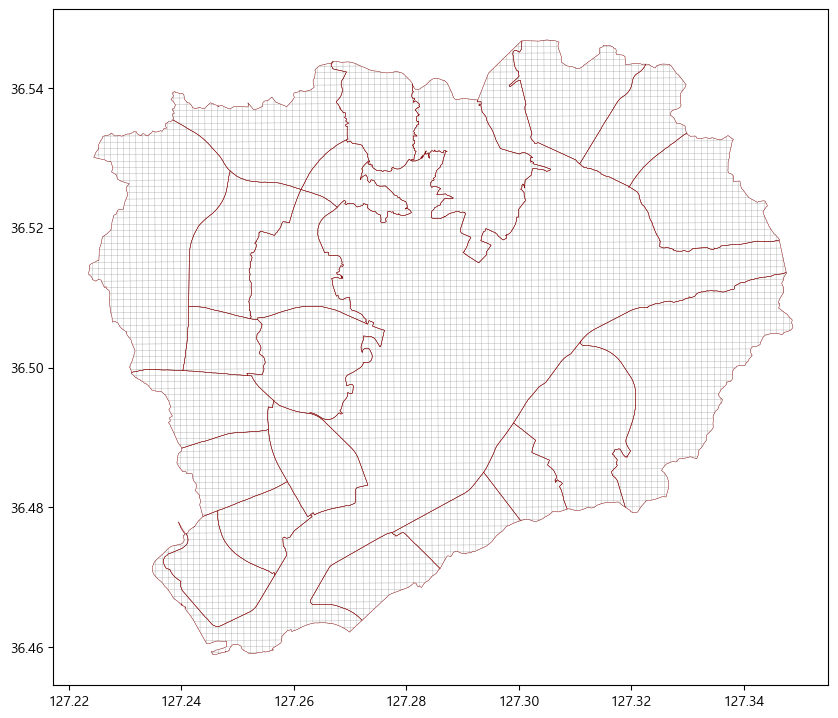

In [30]:
# ax 객체 생성
fig, ax = plt.subplots(figsize=(10, 10))
# ax.axis('off')

# 필터링된 겹치는 부분만 플롯
area_grid_intsc.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.1)
sejong_zone_adm_boundary.plot(ax=ax, facecolor='none', edgecolor='DarkRed', linewidth=0.3)

plt.show()

# | 상가 영업 폐업 현황 파악

# 2. 데이터 정리

## 2.1. 데이터 로드

In [31]:
sanga = pd.read_csv('00data/5.세종시_상가개폐업정보.csv')
category = pd.read_csv('00data/0.지방행정인허가데이터개방_업종코드_업종별영업상태코드목록v2.9.csv')

## 2.1.1. 상가 개폐업 정보 데이터

### # 데이터 파악

In [32]:
print(sanga.shape)
sanga.iloc[25000:25003,:]

(43974, 20)


,service_nm,lcpmt_dt,rtrcn_dt,biz_stts_cd,biz_stts_nm,dtls_stts_cd,dtls_stts_nm,cls_date,tc_strt_dt,tc_end_dt,re_op_dt,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat
25000,일반음식점,2024-04-30,NaN,1,영업/정상,NaN,영업,NaN,NaN,NaN,NaN,35.62,339-009,세종특별자치시 새롬동 593 새뜸마을6단지,세종특별자치시 새롬중앙1로 13 상가2동 지1층 105호 (새롬동 새뜸마을6단지),NaN,청달방,기타,127.250117,36.484093
25001,일반음식점,2024-04-30,NaN,1,영업/정상,NaN,영업,NaN,NaN,NaN,NaN,21.75,339-883,세종특별자치시 조치원읍 원리 6-19,세종특별자치시 조치원읍 새내10길 19 1층 30호,NaN,주막카세,한식,127.299311,36.600737
25002,일반음식점,2024-05-01,NaN,1,영업/정상,NaN,영업,NaN,NaN,NaN,NaN,38.28,339-013,세종특별자치시 종촌동 657 종촌 중앙프라자,세종특별자치시 도움3로 105-5 종촌 중앙프라자 1층 103호 (종촌동),NaN,본죽&비빔밥 세종종촌점,한식,127.249531,36.504769


1955-10-29 00:00:00
2024-05-31 00:00:00


<Axes: >

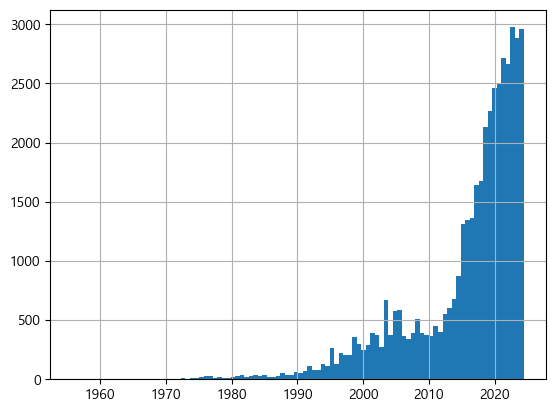

In [33]:
sanga['lcpmt_dt'] = pd.to_datetime(sanga['lcpmt_dt'], errors='coerce')
print(sanga['lcpmt_dt'].min())
print(sanga['lcpmt_dt'].max())
# 날짜 히스토그램
sanga['lcpmt_dt'].hist(bins=100) #히스토그램 막대 100개

In [34]:
# 주소지 전처리
sanga[['addr', 'rd_addr', 'bplc_nm']] = sanga[['addr', 'rd_addr', 'bplc_nm']].apply(lambda x: x.str.replace(r'\s+', ' ', regex=True))
sanga[['addr', 'rd_addr', 'bplc_nm']] = sanga[['addr', 'rd_addr', 'bplc_nm']].apply(lambda x: x.str.strip())
sanga[['addr', 'rd_addr', 'bplc_nm']].head(3)

,addr,rd_addr,bplc_nm
0,세종특별자치시 전동면 청람리 21-1,세종특별자치시 전동면 운주산로 720-6,청수환경
1,세종특별자치시 조치원읍 죽림리 389 죽림푸르지오,세종특별자치시 조치원읍 죽림본로 33-6 104동 1304호 (죽림푸르지오),하랑 영농조합법인
2,세종특별자치시 소정면 대곡리 368-8,세종특별자치시 소정면 학수소사길 63,(주)금강피스코


### # 대상지 내 데이터만 추출

In [38]:
# 대상구역계 안에 있는 상가들만 추출: 23268개
sejong_zone = gpd.read_file('00data/11.세종시_대상구역도.geojson')
geo_sanga = gpd.GeoDataFrame(sanga, geometry=gpd.points_from_xy(sanga.lon, sanga.lat))
zone_sanga = gpd.sjoin(geo_sanga, sejong_zone, how='inner', predicate='within')
print(zone_sanga.shape)
zone_sanga

(23268, 25)


,service_nm,lcpmt_dt,rtrcn_dt,biz_stts_cd,biz_stts_nm,dtls_stts_cd,dtls_stts_nm,cls_date,tc_strt_dt,tc_end_dt,re_op_dt,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right,EMD_CD,COL_ADM_SE,EMD_NM
56,가축사육업,2004-11-05,NaN,4,취소/말소/만료/정지/중지,NaN,행정처분,NaN,NaN,NaN,NaN,0.00,339-863,세종특별자치시 연동면 합강리 ***-*번지,세종특별자치시 연동면 원합강*길 **,NaN,합강목장,NaN,127.332681,36.525324,POINT (127.33268 36.52532),16,36110117,36110,합강동
75,가축사육업,2004-11-10,NaN,4,취소/말소/만료/정지/중지,NaN,행정처분,NaN,NaN,NaN,NaN,0.00,339-834,세종특별자치시 금남면 집현리 ***-***번지,세종특별자치시 금남면 금병로 ***-**,NaN,한림농장,NaN,127.324269,36.487788,POINT (127.32427 36.48779),17,36110118,36110,집현동
111,가축사육업,2004-12-27,NaN,3,폐업,NaN,폐업,2007-05-08,NaN,NaN,NaN,0.00,339-834,세종특별자치시 금남면 집현리 ***-***번지,세종특별자치시 금남면 금병로 ***-**,NaN,금호농장,NaN,127.326992,36.491780,POINT (127.32699 36.49178),17,36110118,36110,집현동
112,가축사육업,2004-12-27,NaN,4,취소/말소/만료/정지/중지,NaN,행정처분,NaN,NaN,NaN,NaN,0.00,339-834,세종특별자치시 반곡동 ***-*번지,NaN,NaN,창원,NaN,127.313923,36.496989,POINT (127.31392 36.49699),0,36110101,36110,반곡동
118,가축사육업,2004-12-29,NaN,4,취소/말소/만료/정지/중지,NaN,행정처분,NaN,NaN,NaN,NaN,0.00,339-834,세종특별자치시 금남면 집현리 ***-***번지,세종특별자치시 금남면 석교길 **,NaN,석교농장,NaN,127.317713,36.485078,POINT (127.31771 36.48508),17,36110118,36110,집현동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43969,휴게음식점,2024-05-27,NaN,1,영업/정상,NaN,영업,NaN,NaN,NaN,NaN,3.30,NaN,세종특별자치시 해밀동 334 해밀마을1단지,세종특별자치시 해밀3로 32 상가동 1층 140호 (해밀동 해밀마을1단지),NaN,이마트24 세종해밀마을점,기타 휴게음식점,127.267367,36.524934,POINT (127.26737 36.52493),15,36110116,36110,해밀동
43970,휴게음식점,2024-05-28,NaN,1,영업/정상,NaN,영업,NaN,NaN,NaN,NaN,49.50,339-005,세종특별자치시 대평동 732,세종특별자치시 금남구즉로 19 1층 101호 (대평동),NaN,카페시온,커피숍,127.282880,36.469593,POINT (127.28288 36.46959),3,36110104,36110,대평동
43971,휴게음식점,2024-05-28,NaN,1,영업/정상,NaN,영업,NaN,NaN,NaN,NaN,46.39,NaN,세종특별자치시 산울동 138 산울마을6단지,세종특별자치시 산울2로 10 근린생활시설B동 B-107호 (산울동 산울마을6단지),NaN,컴포즈커피 세종산울점,커피숍,127.263296,36.528581,POINT (127.2633 36.52858),14,36110115,36110,산울동
43972,휴게음식점,2024-05-30,NaN,1,영업/정상,NaN,영업,NaN,NaN,NaN,NaN,NaN,NaN,세종특별자치시 세종동 1204,세종특별자치시 중앙공원로 60 세종시 중앙공원 도시축제마당 (세종동),NaN,소담곳간,기타 휴게음식점,127.276219,36.494760,POINT (127.27622 36.49476),18,36110119,36110,세종동


In [40]:
# lcpmt_dt 열을 datetime으로 변환 (잘못된 형식은 NaT로 변환)
zone_sanga['lcpmt_dt'] = pd.to_datetime(zone_sanga['lcpmt_dt'], errors='coerce')

# cls_date 열을 datetime으로 변환 (잘못된 형식은 NaT로 변환)
zone_sanga['cls_date'] = pd.to_datetime(zone_sanga['cls_date'], errors='coerce')

# 개업일(lcpmt_dt) 순으로 정렬
zone_sanga = zone_sanga.sort_values(by='lcpmt_dt')

# 결과 확인
print(zone_sanga.shape)
zone_sanga.head(3)


(23268, 25)


,service_nm,lcpmt_dt,rtrcn_dt,biz_stts_cd,biz_stts_nm,dtls_stts_cd,dtls_stts_nm,cls_date,tc_strt_dt,tc_end_dt,re_op_dt,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right,EMD_CD,COL_ADM_SE,EMD_NM
41352,휴게음식점,1974-05-16,NaN,3,폐업,NaN,폐업,2014-04-18,NaN,NaN,NaN,NaN,339-012,세종특별자치시 어진동 110-6번지,NaN,NaN,수다실,다방,127.261170,36.501689,POINT (127.26117 36.50169),9,36110110,36110,어진동
16418,일반음식점,1974-06-29,NaN,3,폐업,NaN,폐업,2018-11-09,NaN,NaN,NaN,27.82,339-014,세종특별자치시 한솔동 0번지 행복도시B-1블록 첫마을아파트 상가동 B101호,세종특별자치시 누리로 119 상가동 지하1층 B101호 (한솔동 첫마을아파트4단지),NaN,오셰프,기타,127.252174,36.480617,POINT (127.25217 36.48062),5,36110106,36110,한솔동
4008,담배소매업,1975-07-01,NaN,3,폐업,NaN,폐업처리,2007-06-19,NaN,NaN,NaN,NaN,NaN,세종특별자치시 금남면 집현리 785-74번지,NaN,NaN,새가게,NaN,127.323478,36.490075,POINT (127.32348 36.49008),17,36110118,36110,집현동


### # 영업상태에 따른 상가 현황 파악

In [41]:
# 영업상태 고유값 확인
zone_sanga['biz_stts_nm'].unique()

array(['폐업', '영업/정상', '취소/말소/만료/정지/중지', '휴업'], dtype=object)

In [42]:
# 영업/정상 or 폐업으로만 분리
zone_sanga = zone_sanga[(zone_sanga['biz_stts_nm'] == '영업/정상') | (zone_sanga['biz_stts_nm'] == '폐업')]

In [43]:
# zone_sanga 필요없는 열 제거
zone_sanga = zone_sanga.drop(columns=['rtrcn_dt','dtls_stts_cd','dtls_stts_nm','tc_strt_dt','tc_end_dt','re_op_dt'])

print(zone_sanga.shape) # (23268,25) => (22865,19)
zone_sanga.head(3)

(22865, 19)


,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right,EMD_CD,COL_ADM_SE,EMD_NM
41352,휴게음식점,1974-05-16,3,폐업,2014-04-18,NaN,339-012,세종특별자치시 어진동 110-6번지,NaN,NaN,수다실,다방,127.261170,36.501689,POINT (127.26117 36.50169),9,36110110,36110,어진동
16418,일반음식점,1974-06-29,3,폐업,2018-11-09,27.82,339-014,세종특별자치시 한솔동 0번지 행복도시B-1블록 첫마을아파트 상가동 B101호,세종특별자치시 누리로 119 상가동 지하1층 B101호 (한솔동 첫마을아파트4단지),NaN,오셰프,기타,127.252174,36.480617,POINT (127.25217 36.48062),5,36110106,36110,한솔동
4008,담배소매업,1975-07-01,3,폐업,2007-06-19,NaN,NaN,세종특별자치시 금남면 집현리 785-74번지,NaN,NaN,새가게,NaN,127.323478,36.490075,POINT (127.32348 36.49008),17,36110118,36110,집현동


In [44]:
zone_sanga['biz_stts_nm'].unique()

array(['폐업', '영업/정상'], dtype=object)

## 2.1.2. 지방행정인허가 데이터 (업종별 대분류 확인)

### # 데이터 파악

In [45]:
print(category.shape)
category

(198, 7)


,카테고리 분류코드,카테고리 분류명,업종그룹코드,업종그룹명,업종코드,업종명,비고
0,1.0,건강,1.0,의료기관,01_01_01_P,병원,NaN
1,NaN,NaN,NaN,NaN,01_01_02_P,의원,NaN
2,NaN,NaN,NaN,NaN,01_01_03_P,부속의료기관,NaN
3,NaN,NaN,NaN,NaN,01_01_04_P,산후조리업,NaN
4,NaN,NaN,NaN,NaN,01_01_05_P,안전상비의약품 판매업소,NaN
...,...,...,...,...,...,...,...
193,NaN,NaN,49.0,전문교육기관,11_49_01_P,요양보호사교육기관,NaN
194,NaN,NaN,NaN,NaN,11_49_02_P,장례지도사 교육기관,NaN
195,NaN,NaN,50.0,사무지원,11_50_01_P,무료직업소개소,NaN
196,NaN,NaN,NaN,NaN,11_50_02_P,유료직업소개소,NaN


In [46]:
category = category.fillna(method='ffill')
category

,카테고리 분류코드,카테고리 분류명,업종그룹코드,업종그룹명,업종코드,업종명,비고
0,1.0,건강,1.0,의료기관,01_01_01_P,병원,NaN
1,1.0,건강,1.0,의료기관,01_01_02_P,의원,NaN
2,1.0,건강,1.0,의료기관,01_01_03_P,부속의료기관,NaN
3,1.0,건강,1.0,의료기관,01_01_04_P,산후조리업,NaN
4,1.0,건강,1.0,의료기관,01_01_05_P,안전상비의약품 판매업소,NaN
...,...,...,...,...,...,...,...
193,11.0,기타,49.0,전문교육기관,11_49_01_P,요양보호사교육기관,삭제
194,11.0,기타,49.0,전문교육기관,11_49_02_P,장례지도사 교육기관,삭제
195,11.0,기타,50.0,사무지원,11_50_01_P,무료직업소개소,삭제
196,11.0,기타,50.0,사무지원,11_50_02_P,유료직업소개소,삭제


### # 필요한 컬럼 추출 및 컬럼명 변경

In [47]:
# 필요없는 열 제거 (코드 관련 열)
category = category.drop(columns=['카테고리 분류코드','업종그룹코드','업종코드','비고'])
category

,카테고리 분류명,업종그룹명,업종명
0,건강,의료기관,병원
1,건강,의료기관,의원
2,건강,의료기관,부속의료기관
3,건강,의료기관,산후조리업
4,건강,의료기관,안전상비의약품 판매업소
...,...,...,...
193,기타,전문교육기관,요양보호사교육기관
194,기타,전문교육기관,장례지도사 교육기관
195,기타,사무지원,무료직업소개소
196,기타,사무지원,유료직업소개소


In [48]:
# 열 이름 변경
category = category.rename(columns={'카테고리 분류명':'major','업종그룹명':'group','업종명': 'service_nm'})
category

,major,group,service_nm
0,건강,의료기관,병원
1,건강,의료기관,의원
2,건강,의료기관,부속의료기관
3,건강,의료기관,산후조리업
4,건강,의료기관,안전상비의약품 판매업소
...,...,...,...
193,기타,전문교육기관,요양보호사교육기관
194,기타,전문교육기관,장례지도사 교육기관
195,기타,사무지원,무료직업소개소
196,기타,사무지원,유료직업소개소


## 2.1.3. 상가개폐업 데이터 + 지방행정인허가 데이터

In [49]:
zone_sanga_cat = pd.merge(zone_sanga, category, how='left', on='service_nm')
print(zone_sanga_cat.shape)
zone_sanga_cat.head(3)

(22865, 21)


,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right,EMD_CD,COL_ADM_SE,EMD_NM,major,group
0,휴게음식점,1974-05-16,3,폐업,2014-04-18,NaN,339-012,세종특별자치시 어진동 110-6번지,NaN,NaN,수다실,다방,127.261170,36.501689,POINT (127.26117 36.50169),9,36110110,36110,어진동,식품,음식점
1,일반음식점,1974-06-29,3,폐업,2018-11-09,27.82,339-014,세종특별자치시 한솔동 0번지 행복도시B-1블록 첫마을아파트 상가동 B101호,세종특별자치시 누리로 119 상가동 지하1층 B101호 (한솔동 첫마을아파트4단지),NaN,오셰프,기타,127.252174,36.480617,POINT (127.25217 36.48062),5,36110106,36110,한솔동,식품,음식점
2,담배소매업,1975-07-01,3,폐업,2007-06-19,NaN,NaN,세종특별자치시 금남면 집현리 785-74번지,NaN,NaN,새가게,NaN,127.323478,36.490075,POINT (127.32348 36.49008),17,36110118,36110,집현동,기타,담배


In [29]:
# 원하는 컬럼 순서 정의
cols = ['EMD_CD','COL_ADM_SE','EMD_NM','major','group','service_nm'] + [col for col in zone_sanga_cat.columns if col not in ['EMD_CD','COL_ADM_SE','EMD_NM','major','group','service_nm']]
# 컬럼 순서 변경
zone_sanga_cat = zone_sanga_cat[cols]
print(zone_sanga_cat.shape)
zone_sanga_cat.head()

(22865, 21)


,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
0,36110110,36110,어진동,식품,음식점,휴게음식점,1974-05-16,3,폐업,2014-04-18,NaN,339-012,세종특별자치시 어진동 110-6번지,NaN,NaN,수다실,다방,127.261170,36.501689,POINT (127.26117 36.50169),9
1,36110106,36110,한솔동,식품,음식점,일반음식점,1974-06-29,3,폐업,2018-11-09,27.82,339-014,세종특별자치시 한솔동 0번지 행복도시B-1블록 첫마을아파트 상가동 B101호,세종특별자치시 누리로 119 상가동 지하1층 B101호 (한솔동 첫마을아파트4단지),NaN,오셰프,기타,127.252174,36.480617,POINT (127.25217 36.48062),5
2,36110118,36110,집현동,기타,담배,담배소매업,1975-07-01,3,폐업,2007-06-19,NaN,NaN,세종특별자치시 금남면 집현리 785-74번지,NaN,NaN,새가게,NaN,127.323478,36.490075,POINT (127.32348 36.49008),17
3,36110121,36110,한별동,식품,식품 제조/가공/판매,식품제조가공업,1976-10-27,3,폐업,2003-04-10,NaN,339-825,세종특별자치시 연기면 한별리 92-1번지,NaN,NaN,오케이식품,식품제조가공업,127.280942,36.539398,POINT (127.28094 36.53940),20
4,36110119,36110,세종동,식품,식품 제조/가공/판매,즉석판매제조가공업,1979-01-20,3,폐업,2010-11-01,NaN,339-821,세종특별자치시 연기면 세종리 735-239,NaN,NaN,성전가공소,즉석판매제조가공업,127.282061,36.503655,POINT (127.28206 36.50365),18


# 2.2. "업종별" 상가 개수 및 폐업률 현황 ('영업/정상'과 '폐업' 상가 각각 파악)

### # '영업/정상' 과 '폐업' 각각 변수 지정

In [30]:
# "영업/정상"인 행만 추출
zone_sanga_op = zone_sanga_cat[zone_sanga_cat['biz_stts_nm'] == '영업/정상']
print(zone_sanga_op.shape)
zone_sanga_op

(14188, 21)


,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
9,36110101,36110,반곡동,기타,미디어,출판사,1981-08-11,1,영업/정상,NaT,NaN,NaN,세종특별자치시 반곡동 ***-**,세종특별자치시 국책연구원로 ** (반곡동 한국법제연구원),30147,한국법제연구원,NaN,127.302147,36.492206,POINT (127.30215 36.49221),0
14,36110101,36110,반곡동,기타,미디어,출판사,1983-07-07,1,영업/정상,NaT,NaN,NaN,세종특별자치시 반곡동 *** 나라키움 세종국책연구단지,세종특별자치시 시청대로 *** 나라키움 세종국책연구단지 경제정책동 (반곡동),30147,산업연구원,NaN,127.304607,36.496378,POINT (127.30461 36.49638),0
26,36110101,36110,반곡동,기타,미디어,출판사,1988-09-13,1,영업/정상,NaT,NaN,339-007,세종특별자치시 반곡동 ***,세종특별자치시 시청대로 *** 경제정책동 *층 ***호 (반곡동),339-007,한국노동연구원,NaN,127.304607,36.496378,POINT (127.30461 36.49638),0
34,36110101,36110,반곡동,기타,미디어,출판사,1990-11-06,1,영업/정상,NaT,NaN,NaN,세종특별자치시 반곡동 ***,세종특별자치시 시청대로 *** (반곡동 나라키움 세종국책연구단지),30147,대외경제정책연구원,NaN,127.304607,36.496378,POINT (127.30461 36.49638),0
57,36110101,36110,반곡동,기타,미디어,출판사,1993-10-23,1,영업/정상,NaT,NaN,NaN,세종특별자치시 반곡동 *** 나라키움 세종국책연구단지,세종특별자치시 시청대로 *** 나라키움 세종국책연구단지 *~*층 (반곡동),30147,한국청소년정책연구원,NaN,127.304607,36.496378,POINT (127.30461 36.49638),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22859,36110110,36110,어진동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-31,1,영업/정상,NaT,0.78,339-012,세종특별자치시 어진동 670 에비뉴힐,세종특별자치시 갈매로 353 에비뉴힐 A동 2층 2007(일부)호 (어진동),NaN,내맘에 꽃청,즉석판매제조가공업,127.262395,36.495601,POINT (127.26240 36.49560),9
22860,36110107,36110,나성동,생활,유통,통신판매업,2024-05-31,1,영업/정상,NaT,NaN,NaN,세종특별자치시 나성동 *** 나릿재마을*단지,세종특별자치시 국세청로 ** 상가동 B***호 (나성동 나릿재마을*단지),30128,이마트24 세종풍경채점,종합몰,127.261964,36.489109,POINT (127.26196 36.48911),6
22861,36110104,36110,대평동,식품,식품 제조/가공/판매,건강기능식품일반판매업,2024-05-31,1,영업/정상,NaT,3.30,339-005,세종특별자치시 대평동 *** 아마존타워,세종특별자치시 시청대로 ** 아마존타워 *층 ***호 (대평동),NaN,광고혁명,NaN,127.275330,36.474465,POINT (127.27533 36.47446),3
22862,36110110,36110,어진동,생활,유통,통신판매업,2024-05-31,1,영업/정상,NaT,NaN,NaN,세종특별자치시 어진동 *** 세종파이낸스센터,세종특별자치시 갈매로 *** 세종파이낸스센터 ***-D**호 (어진동),30121,도도랑,종합몰,127.262829,36.496339,POINT (127.26283 36.49634),9


In [31]:
# "폐업"인 행만 추출
zone_sanga_cl = zone_sanga_cat[zone_sanga_cat['biz_stts_nm'] == '폐업']
print(zone_sanga_cl.shape)
zone_sanga_cl

(8677, 21)


,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
0,36110110,36110,어진동,식품,음식점,휴게음식점,1974-05-16,3,폐업,2014-04-18,NaN,339-012,세종특별자치시 어진동 110-6번지,NaN,NaN,수다실,다방,127.261170,36.501689,POINT (127.26117 36.50169),9
1,36110106,36110,한솔동,식품,음식점,일반음식점,1974-06-29,3,폐업,2018-11-09,27.82,339-014,세종특별자치시 한솔동 0번지 행복도시B-1블록 첫마을아파트 상가동 B101호,세종특별자치시 누리로 119 상가동 지하1층 B101호 (한솔동 첫마을아파트4단지),NaN,오셰프,기타,127.252174,36.480617,POINT (127.25217 36.48062),5
2,36110118,36110,집현동,기타,담배,담배소매업,1975-07-01,3,폐업,2007-06-19,NaN,NaN,세종특별자치시 금남면 집현리 785-74번지,NaN,NaN,새가게,NaN,127.323478,36.490075,POINT (127.32348 36.49008),17
3,36110121,36110,한별동,식품,식품 제조/가공/판매,식품제조가공업,1976-10-27,3,폐업,2003-04-10,NaN,339-825,세종특별자치시 연기면 한별리 92-1번지,NaN,NaN,오케이식품,식품제조가공업,127.280942,36.539398,POINT (127.28094 36.53940),20
4,36110119,36110,세종동,식품,식품 제조/가공/판매,즉석판매제조가공업,1979-01-20,3,폐업,2010-11-01,NaN,339-821,세종특별자치시 연기면 세종리 735-239,NaN,NaN,성전가공소,즉석판매제조가공업,127.282061,36.503655,POINT (127.28206 36.50365),18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22777,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-26,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 (나성동),NaN,달빛제유소,즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22782,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-25,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 도시상징광장 (나성동),NaN,주식회사 세종시한글빵(단비캐릭터 솜사탕),즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22824,36110106,36110,한솔동,건강,의료기기,의료기기판매(임대)업,2024-05-28,3,폐업,2024-06-04,NaN,NaN,세종특별자치시 한솔동 *** 첫마을*단지,세종특별자치시 나리로 ** 상가동 지*층 비***호 (한솔동 첫마을*단지),30130,지에스25 세종래미안점,NaN,127.256030,36.473031,POINT (127.25603 36.47303),5
22832,36110110,36110,어진동,건강,의료기기,의료기기판매(임대)업,2024-05-29,3,폐업,2024-05-29,NaN,NaN,세종특별자치시 어진동 ***번지 세종비지니스센터 세종세무서,세종특별자치시 가름로 *** 세종비지니스센터 세종세무서 *층 ***호 (어진동),30121,Smart dental mall,NaN,127.264908,36.495627,POINT (127.26491 36.49563),9


#### # 결측치 제거

In [32]:
# 결측치 행 개수 파악
print(zone_sanga_cl['lcpmt_dt'].isna().sum()) # "폐업" 내 "지정일자(lcpmt_dt)" 결측치 행 개수 파악
print(zone_sanga_cl['cls_date'].isna().sum()) # "폐업" 내 "영업종료(cls_date)" 결측치 행 개수 파악
print(zone_sanga_op['lcpmt_dt'].isna().sum()) # "영업" 내 "지정일자(lcpmt_dt)" 결측치 행 개수 파악
print(zone_sanga_op['cls_date'].isna().sum()) # "영업" 내 "영업종료(cls_date)" 결측치 행 개수 파악 # 결측치 개수 = 총 행 개수 인게 맞는지 확인

1
21
0
14188


In [33]:
# 결측치 행 위치 파악
print(zone_sanga_cl[zone_sanga_cl['lcpmt_dt'].isna()].index) # "폐업" 내 "지정일자(lcpmt_dt)" 결측치 행 위치 파악
print(zone_sanga_cl[zone_sanga_cl['cls_date'].isna()].index) # "폐업" 내 "영업종료(cls_date)" 결측치 행 위치 파악

Int64Index([22864], dtype='int64')
Int64Index([   18,    84,    85,   138,   207,   259,   566,   666,  1041,
             2097,  2803,  5854,  6297,  7285,  8011,  8048,  9108,  9121,
            10197, 10206, 12424],
           dtype='int64')


In [34]:
# "폐업" 내 "지정일자(lcpmt_dt)" 결측치 행 전체 확인
zone_sanga_cl[zone_sanga_cl['lcpmt_dt'].isna()]

,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
22864,36110101,36110,반곡동,기타,담배,담배소매업,NaT,3,폐업,2006-09-20,NaN,NaN,세종특별자치시 반곡동 375-4번지,NaN,NaN,효정슈퍼,NaN,127.311858,36.49497,POINT (127.31186 36.49497),0


In [35]:
# "폐업" 내 "영업종료(cls_date)" 결측치 행 전체 확인
zone_sanga_cl[zone_sanga_cl['cls_date'].isna()]

,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
18,36110118,36110,집현동,자원환경,환경관리,대기오염물질배출시설설치사업장,1984-05-30,3,폐업,NaT,NaN,339-834,세종특별자치시 금남면 집현리 193번지,세종특별자치시 금남면 금강변길 821,339-834,한일산업(주) 조치원공장,NaN,127.316945,36.505913,POINT (127.31695 36.50591),17
84,36110111,36110,종촌동,자원환경,환경관리,수질오염원설치시설(기타),1995-05-19,3,폐업,NaT,NaN,314-912,세종특별자치시 종촌동 179-3,NaN,NaN,만수양어,양식어업,127.245585,36.505286,POINT (127.24559 36.50529),10
85,36110111,36110,종촌동,자원환경,환경관리,수질오염원설치시설(기타),1995-05-19,3,폐업,NaT,NaN,314-910,세종특별자치시 종촌동 179-0,NaN,NaN,만수양어,양식어업,127.245604,36.505611,POINT (127.24560 36.50561),10
138,36110103,36110,보람동,식품,식품 제조/가공/판매,축산가공업,1998-09-05,3,폐업,NaT,0.0,NaN,세종특별자치시 보람동 38-1번지,NaN,NaN,충청영농조합법인,식육가공업,127.296888,36.477410,POINT (127.29689 36.47741),2
207,36110112,36110,고운동,자원환경,환경관리,대기오염물질배출시설설치사업장,2001-09-05,3,폐업,NaT,NaN,NaN,세종특별자치시 고운동 584-0번지,NaN,NaN,혜성리싸이클,그외 기타 플라스틱제품 제조업,127.236661,36.532540,POINT (127.23666 36.53254),11
259,36110104,36110,대평동,자원환경,지하수,지하수시공업체,2003-07-30,3,폐업,NaT,NaN,NaN,세종특별자치시 대평동 265-24번지,NaN,NaN,(주)동욱ENG,NaN,127.275183,36.471286,POINT (127.27518 36.47129),3
566,36110120,36110,누리동,자원환경,환경관리,대기오염물질배출시설설치사업장,2012-07-01,3,폐업,NaT,NaN,NaN,세종특별자치시 연기면 누리리 194-12번지,세종특별자치시 연기면 월산공단로 223-14,339-824,(주)씨엔에이,화합물 및 화학제품 제조업,127.293055,36.531150,POINT (127.29306 36.53115),19
666,36110120,36110,누리동,자원환경,환경관리,대기오염물질배출시설설치사업장,2013-01-11,3,폐업,NaT,NaN,NaN,세종특별자치시 연기면 누리리 194-45번지 월산산업단지,세종특별자치시 연기면 원수산로 129 (월산산업단지),NaN,한국환경공단 연기중간처리사업소,NaN,127.292986,36.517332,POINT (127.29299 36.51733),19
1041,36110110,36110,어진동,자원환경,지하수,지하수시공업체,2014-05-12,3,폐업,NaT,NaN,NaN,NaN,세종특별자치시 갈매로 351 에비뉴힐 B동 4133호 (어진동),NaN,(주)세종이엔텍,NaN,127.262162,36.495135,POINT (127.26216 36.49514),9
2097,36110114,36110,도담동,자원환경,목재,원목생산업,2015-07-27,3,폐업,NaT,NaN,NaN,NaN,세종특별자치시 보듬4로 19 1204동 101호 (도담동 도램마을 12단지),30098,***,NaN,127.261940,36.513573,POINT (127.26194 36.51357),13


In [36]:
# 결측치 행 제거
zone_sanga_cl = zone_sanga_cl.dropna(subset=['lcpmt_dt'])
zone_sanga_cl = zone_sanga_cl.dropna(subset=['cls_date'])

In [37]:
# 결측치 행 개수 파악
print(zone_sanga_cl['lcpmt_dt'].isna().sum()) # "폐업" 내 "지정일자(lcpmt_dt)" 결측치 행 개수 파악
print(zone_sanga_cl['cls_date'].isna().sum()) # "폐업" 내 "영업종료(cls_date)" 결측치 행 개수 파악

0
0


#### # 2012년 이후 데이터만 추출

In [38]:
import pandas as pd

# 두 데이터프레임을 로드하거나 이미 로드된 데이터프레임을 사용한다고 가정합니다.
# zone_sanga_op_cnt와 zone_sanga_cl_cnt 데이터프레임이 있다고 가정합니다.

# 날짜 형식 변환
zone_sanga_op['lcpmt_dt'] = pd.to_datetime(zone_sanga_op['lcpmt_dt'], errors='coerce')
zone_sanga_op['cls_date'] = pd.to_datetime(zone_sanga_op['cls_date'], errors='coerce')

zone_sanga_cl['lcpmt_dt'] = pd.to_datetime(zone_sanga_cl['lcpmt_dt'], errors='coerce')
zone_sanga_cl['cls_date'] = pd.to_datetime(zone_sanga_cl['cls_date'], errors='coerce')

# lcpmt_dt(지정일자)열과 cls_date(폐업일자) 두 열 모두 2012년 이후 고려
zone_sanga_op = zone_sanga_op[
    (zone_sanga_op['lcpmt_dt'] >= '2012-01-01') |
    (zone_sanga_op['cls_date'] >= '2012-01-01')
]

zone_sanga_cl = zone_sanga_cl[
    (zone_sanga_cl['lcpmt_dt'] >= '2012-01-01') |
    (zone_sanga_cl['cls_date'] >= '2012-01-01')
]

# 결과 확인
print(zone_sanga_op)
print(zone_sanga_cl)


         EMD_CD COL_ADM_SE EMD_NM major        group   service_nm   lcpmt_dt  \
501    36110102      36110    소담동    생활           유통        통신판매업 2012-01-10   
503    36110104      36110    대평동    생활           미용          미용업 2012-01-17   
504    36110107      36110    나성동    기타         사무지원      유료직업소개소 2012-01-19   
505    36110112      36110    고운동    생활           유통        통신판매업 2012-02-01   
514    36110106      36110    한솔동    식품          음식점        일반음식점 2012-02-14   
...         ...        ...    ...   ...          ...          ...        ...   
22859  36110110      36110    어진동    식품  식품 제조/가공/판매    즉석판매제조가공업 2024-05-31   
22860  36110107      36110    나성동    생활           유통        통신판매업 2024-05-31   
22861  36110104      36110    대평동    식품  식품 제조/가공/판매  건강기능식품일반판매업 2024-05-31   
22862  36110110      36110    어진동    생활           유통        통신판매업 2024-05-31   
22863  36110106      36110    한솔동    기타           담배        담배소매업 2024-05-31   

       biz_stts_cd biz_stts_nm cls_date

In [39]:
zone_sanga_cl

,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
0,36110110,36110,어진동,식품,음식점,휴게음식점,1974-05-16,3,폐업,2014-04-18,NaN,339-012,세종특별자치시 어진동 110-6번지,NaN,NaN,수다실,다방,127.261170,36.501689,POINT (127.26117 36.50169),9
1,36110106,36110,한솔동,식품,음식점,일반음식점,1974-06-29,3,폐업,2018-11-09,27.82,339-014,세종특별자치시 한솔동 0번지 행복도시B-1블록 첫마을아파트 상가동 B101호,세종특별자치시 누리로 119 상가동 지하1층 B101호 (한솔동 첫마을아파트4단지),NaN,오셰프,기타,127.252174,36.480617,POINT (127.25217 36.48062),5
7,36110119,36110,세종동,식품,음식점,일반음식점,1980-12-27,3,폐업,2013-02-21,NaN,339-003,세종특별자치시 나성동 101번지,NaN,NaN,금강집,정종/대포집/소주방,127.270526,36.480488,POINT (127.27053 36.48049),18
17,36110118,36110,집현동,자원환경,환경관리,대기오염물질배출시설설치사업장,1984-05-30,3,폐업,2016-04-22,NaN,NaN,세종특별자치시 금남면 집현리 202-0번지,세종특별자치시 금남면 금강변길 821,NaN,중원콘택(주),콘크리트 관 및 조립구조재 제조업,127.318325,36.506075,POINT (127.31832 36.50608),17
19,36110110,36110,어진동,식품,음식점,휴게음식점,1984-06-04,3,폐업,2017-12-28,NaN,339-012,세종특별자치시 어진동 76-11번지,NaN,NaN,솔다실,다방,127.260658,36.503812,POINT (127.26066 36.50381),9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22755,36110111,36110,종촌동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-23,3,폐업,2024-05-30,NaN,339-013,세종특별자치시 종촌동 661 스마트빌딩,세종특별자치시 도움3로 105-6 스마트빌딩 1층 이마트에브리데이 세종종촌점 (종촌동),NaN,김찬길 명인 핫바,즉석판매제조가공업,127.249047,36.504569,POINT (127.24905 36.50457),10
22777,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-26,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 (나성동),NaN,달빛제유소,즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22782,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-25,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 도시상징광장 (나성동),NaN,주식회사 세종시한글빵(단비캐릭터 솜사탕),즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22824,36110106,36110,한솔동,건강,의료기기,의료기기판매(임대)업,2024-05-28,3,폐업,2024-06-04,NaN,NaN,세종특별자치시 한솔동 *** 첫마을*단지,세종특별자치시 나리로 ** 상가동 지*층 비***호 (한솔동 첫마을*단지),30130,지에스25 세종래미안점,NaN,127.256030,36.473031,POINT (127.25603 36.47303),5


In [40]:
zone_sanga_op

,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
501,36110102,36110,소담동,생활,유통,통신판매업,2012-01-10,1,영업/정상,NaT,NaN,NaN,세종특별자치시 소담동 *** 법조타운B,세종특별자치시 한누리대로 **** 법조타운B *층 ***호 (소담동),30147,(주)마랑,의류/패션/잡화/뷰티,127.302033,36.489279,POINT (127.30203 36.48928),1
503,36110104,36110,대평동,생활,미용,미용업,2012-01-17,1,영업/정상,NaT,33.57,339-005,세종특별자치시 대평동 668 해들마을 6단지 상가동,세종특별자치시 한누리대로 2236 해들마을 6단지 상가동 2층 C222호 (대평동),NaN,주미 에스테틱,피부미용업,127.278462,36.474994,POINT (127.27846 36.47499),3
504,36110107,36110,나성동,기타,사무지원,유료직업소개소,2012-01-19,1,영업/정상,NaT,NaN,NaN,세종특별자치시 나성동 752 한림프라자,세종특별자치시 한누리대로 219 한림프라자 4층 401 402호 (나성동),30127,(주)지에스씨넷,NaN,127.258974,36.484214,POINT (127.25897 36.48421),6
505,36110112,36110,고운동,생활,유통,통신판매업,2012-02-01,1,영업/정상,NaT,NaN,NaN,세종특별자치시 고운동 **** 금화빌딩,세종특별자치시 고운서길 ** 금화빌딩 *층 ***호 (고운동),30063,주식회사 아이키디아,교육/도서/완구/오락 가구/수납용품 건강/식품 의류/패션/잡화/뷰티,127.234925,36.505729,POINT (127.23493 36.50573),11
514,36110106,36110,한솔동,식품,음식점,일반음식점,2012-02-14,1,영업/정상,NaT,37.00,339-014,세종특별자치시 한솔동 940 첫마을2단지 110호,세종특별자치시 노을3로 19 상가동 110호 (한솔동 첫마을2단지),NaN,압구정 김밥,김밥(도시락),127.259840,36.481451,POINT (127.25984 36.48145),5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22859,36110110,36110,어진동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-31,1,영업/정상,NaT,0.78,339-012,세종특별자치시 어진동 670 에비뉴힐,세종특별자치시 갈매로 353 에비뉴힐 A동 2층 2007(일부)호 (어진동),NaN,내맘에 꽃청,즉석판매제조가공업,127.262395,36.495601,POINT (127.26240 36.49560),9
22860,36110107,36110,나성동,생활,유통,통신판매업,2024-05-31,1,영업/정상,NaT,NaN,NaN,세종특별자치시 나성동 *** 나릿재마을*단지,세종특별자치시 국세청로 ** 상가동 B***호 (나성동 나릿재마을*단지),30128,이마트24 세종풍경채점,종합몰,127.261964,36.489109,POINT (127.26196 36.48911),6
22861,36110104,36110,대평동,식품,식품 제조/가공/판매,건강기능식품일반판매업,2024-05-31,1,영업/정상,NaT,3.30,339-005,세종특별자치시 대평동 *** 아마존타워,세종특별자치시 시청대로 ** 아마존타워 *층 ***호 (대평동),NaN,광고혁명,NaN,127.275330,36.474465,POINT (127.27533 36.47446),3
22862,36110110,36110,어진동,생활,유통,통신판매업,2024-05-31,1,영업/정상,NaT,NaN,NaN,세종특별자치시 어진동 *** 세종파이낸스센터,세종특별자치시 갈매로 *** 세종파이낸스센터 ***-D**호 (어진동),30121,도도랑,종합몰,127.262829,36.496339,POINT (127.26283 36.49634),9


# # 데이터 정제 끝 현황 분석 시작

## 2.2.1. (전체) 상가 "개수" 현황 ('영업/정상'과 '폐업' 상가 각각 파악)

#### # 동일한 사업장명 확인(zone_sanga_op 과 zone_sanga_cl 동일한 사업장명의 영업시작일이 동일할 것이므로)

#### # 총 영업 시작 상가수 = (영업 데이터 내 + 폐업 데이너 내) 영업 시작 상가수 - 중복된 영업 시작 상가수

In [41]:
# 두 데이터프레임을 위-아래로 합치기
zone_sanga_total_op = pd.concat([zone_sanga_op, zone_sanga_cl], axis=0, ignore_index=True)

# 중복 행 제거하기 (bplc_nm과 lcpmt_dt가 동일한 행을 제거)
zone_sanga_total_op = zone_sanga_total_op.drop_duplicates(subset=['bplc_nm', 'lcpmt_dt'], keep=False)

zone_sanga_total_op


,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
0,36110102,36110,소담동,생활,유통,통신판매업,2012-01-10,1,영업/정상,NaT,NaN,NaN,세종특별자치시 소담동 *** 법조타운B,세종특별자치시 한누리대로 **** 법조타운B *층 ***호 (소담동),30147,(주)마랑,의류/패션/잡화/뷰티,127.302033,36.489279,POINT (127.30203 36.48928),1
1,36110104,36110,대평동,생활,미용,미용업,2012-01-17,1,영업/정상,NaT,33.57,339-005,세종특별자치시 대평동 668 해들마을 6단지 상가동,세종특별자치시 한누리대로 2236 해들마을 6단지 상가동 2층 C222호 (대평동),NaN,주미 에스테틱,피부미용업,127.278462,36.474994,POINT (127.27846 36.47499),3
2,36110107,36110,나성동,기타,사무지원,유료직업소개소,2012-01-19,1,영업/정상,NaT,NaN,NaN,세종특별자치시 나성동 752 한림프라자,세종특별자치시 한누리대로 219 한림프라자 4층 401 402호 (나성동),30127,(주)지에스씨넷,NaN,127.258974,36.484214,POINT (127.25897 36.48421),6
3,36110112,36110,고운동,생활,유통,통신판매업,2012-02-01,1,영업/정상,NaT,NaN,NaN,세종특별자치시 고운동 **** 금화빌딩,세종특별자치시 고운서길 ** 금화빌딩 *층 ***호 (고운동),30063,주식회사 아이키디아,교육/도서/완구/오락 가구/수납용품 건강/식품 의류/패션/잡화/뷰티,127.234925,36.505729,POINT (127.23493 36.50573),11
4,36110106,36110,한솔동,식품,음식점,일반음식점,2012-02-14,1,영업/정상,NaT,37.00,339-014,세종특별자치시 한솔동 940 첫마을2단지 110호,세종특별자치시 노을3로 19 상가동 110호 (한솔동 첫마을2단지),NaN,압구정 김밥,김밥(도시락),127.259840,36.481451,POINT (127.25984 36.48145),5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22460,36110111,36110,종촌동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-23,3,폐업,2024-05-30,NaN,339-013,세종특별자치시 종촌동 661 스마트빌딩,세종특별자치시 도움3로 105-6 스마트빌딩 1층 이마트에브리데이 세종종촌점 (종촌동),NaN,김찬길 명인 핫바,즉석판매제조가공업,127.249047,36.504569,POINT (127.24905 36.50457),10
22461,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-26,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 (나성동),NaN,달빛제유소,즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22462,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-25,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 도시상징광장 (나성동),NaN,주식회사 세종시한글빵(단비캐릭터 솜사탕),즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22463,36110106,36110,한솔동,건강,의료기기,의료기기판매(임대)업,2024-05-28,3,폐업,2024-06-04,NaN,NaN,세종특별자치시 한솔동 *** 첫마을*단지,세종특별자치시 나리로 ** 상가동 지*층 비***호 (한솔동 첫마을*단지),30130,지에스25 세종래미안점,NaN,127.256030,36.473031,POINT (127.25603 36.47303),5


#### # 데이터 복제

In [42]:
# 데이터 복제
zone_sanga_op_cnt = zone_sanga_total_op.copy()
zone_sanga_cl_cnt = zone_sanga_cl.copy()

#### # 총 영업 시작 상가수 = (영업 데이터 내 + 폐업 데이너 내) 영업 시작 상가수 - 중복된 영업 시작 상가수

#### # zone_sanga_total_op => 앞에서 정제한 데이터프레임 사용

In [43]:
import pandas as pd
# 영업 데이터 내
# 2012년 이후 영업 시작 상가수를 연도별로 집계
zone_sanga_op_cnt['lcpmt_dt'] = pd.to_datetime(zone_sanga_op_cnt['lcpmt_dt'])

total_op_counts = zone_sanga_op_cnt[zone_sanga_op_cnt['lcpmt_dt'].dt.year >= 2012]
total_op_counts_yearly = total_op_counts.groupby(total_op_counts['lcpmt_dt'].dt.year).size()

total_op_counts_yearly = total_op_counts_yearly.to_frame(name='count')
total_op_counts_yearly.index.name = 'year'
total_op_counts_yearly.reset_index(inplace=True)

print(total_op_counts_yearly.info())
total_op_counts_yearly

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   year    13 non-null     int64
 1   count   13 non-null     int64
dtypes: int64(2)
memory usage: 336.0 bytes
None


,year,count
0,2012,152
1,2013,208
2,2014,624
3,2015,1037
4,2016,1063
5,2017,1542
6,2018,1930
7,2019,2328
8,2020,2521
9,2021,2678


#### # 폐업 데이터 내 "폐업 시작" 상가수

In [44]:
# 폐업 데이터 내
# 2012년 이후 영업 시작 상가수를 연도별로 집계
zone_sanga_cl_cnt['cls_date'] = pd.to_datetime(zone_sanga_cl_cnt['cls_date'])

cl_cl_counts = zone_sanga_cl_cnt[zone_sanga_cl_cnt['cls_date'].dt.year >= 2012]
cl_cl_counts_yearly = cl_cl_counts.groupby(cl_cl_counts['cls_date'].dt.year).size()

cl_cl_counts_yearly = cl_cl_counts_yearly.to_frame(name='count')
cl_cl_counts_yearly.index.name = 'year'
cl_cl_counts_yearly.reset_index(inplace=True)

print(cl_cl_counts_yearly.info())
cl_cl_counts_yearly

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   year    13 non-null     int64
 1   count   13 non-null     int64
dtypes: int64(2)
memory usage: 336.0 bytes
None


,year,count
0,2012,14
1,2013,38
2,2014,50
3,2015,104
4,2016,244
5,2017,410
6,2018,624
7,2019,1039
8,2020,990
9,2021,1131


#### # "총 영업 시작" 상가수 & "폐업 시작" 상가수 하나로 합치기

In [45]:
# year 열을 기준으로 병합total_op_counts_yearly
counts_yearly = pd.merge(total_op_counts_yearly, cl_cl_counts_yearly, how='left', on='year', suffixes=('_open', '_close'))
# 결측값을 0으로 채우기
counts_yearly = counts_yearly.fillna(0)
# count 열을 빼기
counts_yearly['count_substract'] = counts_yearly['count_open'] - counts_yearly['count_close']

# # 불필요한 열 삭제
# counts_yearly = total_op_counts_yearly[['year', 'count']]

# 결과 출력
print(counts_yearly.info)
counts_yearly

<bound method DataFrame.info of     year  count_open  count_close  count_substract
0   2012         152           14              138
1   2013         208           38              170
2   2014         624           50              574
3   2015        1037          104              933
4   2016        1063          244              819
5   2017        1542          410             1132
6   2018        1930          624             1306
7   2019        2328         1039             1289
8   2020        2521          990             1531
9   2021        2678         1131             1547
10  2022        3109         1383             1726
11  2023        3001         1686             1315
12  2024        1525          733              792>


,year,count_open,count_close,count_substract
0,2012,152,14,138
1,2013,208,38,170
2,2014,624,50,574
3,2015,1037,104,933
4,2016,1063,244,819
5,2017,1542,410,1132
6,2018,1930,624,1306
7,2019,2328,1039,1289
8,2020,2521,990,1531
9,2021,2678,1131,1547


# 총 상가 수 시각화

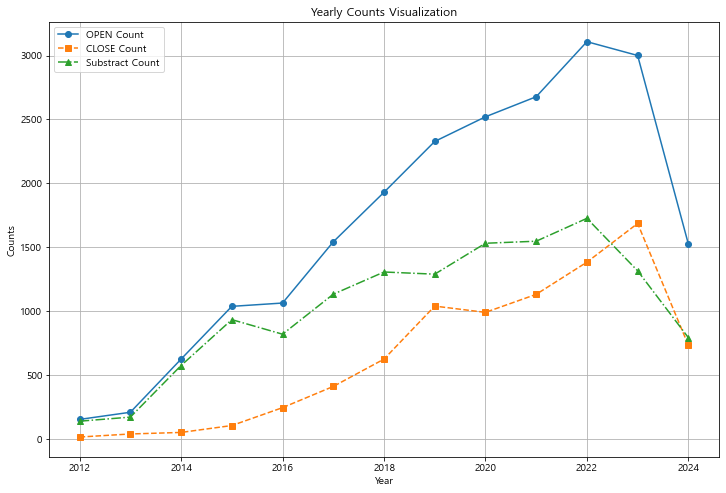

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 시각화
plt.figure(figsize=(12, 8))

# 각 열에 대해 꺾은선 그래프 그리기
plt.plot(counts_yearly['year'], counts_yearly['count_open'], label='OPEN Count', linestyle='-', marker='o')
plt.plot(counts_yearly['year'], counts_yearly['count_close'], label='CLOSE Count', linestyle='--', marker='s')
plt.plot(counts_yearly['year'], counts_yearly['count_substract'], label='Substract Count', linestyle='-.', marker='^')

# 그래프 꾸미기
plt.title('Yearly Counts Visualization')
plt.xlabel('Year')
plt.ylabel('Counts')
plt.legend()
plt.grid(True)

# 그래프 보여주기
plt.show()

## 2.2.2. (행정동별_개수) 상가 "개수" 현황 ('영업/정상'과 '폐업' 상가 각각 파악)

In [47]:
# 데이터 복제
zone_sanga_op_emd = zone_sanga_total_op.copy()
zone_sanga_cl_emd = zone_sanga_cl.copy()

In [48]:
zone_sanga_op_emd

,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
0,36110102,36110,소담동,생활,유통,통신판매업,2012-01-10,1,영업/정상,NaT,NaN,NaN,세종특별자치시 소담동 *** 법조타운B,세종특별자치시 한누리대로 **** 법조타운B *층 ***호 (소담동),30147,(주)마랑,의류/패션/잡화/뷰티,127.302033,36.489279,POINT (127.30203 36.48928),1
1,36110104,36110,대평동,생활,미용,미용업,2012-01-17,1,영업/정상,NaT,33.57,339-005,세종특별자치시 대평동 668 해들마을 6단지 상가동,세종특별자치시 한누리대로 2236 해들마을 6단지 상가동 2층 C222호 (대평동),NaN,주미 에스테틱,피부미용업,127.278462,36.474994,POINT (127.27846 36.47499),3
2,36110107,36110,나성동,기타,사무지원,유료직업소개소,2012-01-19,1,영업/정상,NaT,NaN,NaN,세종특별자치시 나성동 752 한림프라자,세종특별자치시 한누리대로 219 한림프라자 4층 401 402호 (나성동),30127,(주)지에스씨넷,NaN,127.258974,36.484214,POINT (127.25897 36.48421),6
3,36110112,36110,고운동,생활,유통,통신판매업,2012-02-01,1,영업/정상,NaT,NaN,NaN,세종특별자치시 고운동 **** 금화빌딩,세종특별자치시 고운서길 ** 금화빌딩 *층 ***호 (고운동),30063,주식회사 아이키디아,교육/도서/완구/오락 가구/수납용품 건강/식품 의류/패션/잡화/뷰티,127.234925,36.505729,POINT (127.23493 36.50573),11
4,36110106,36110,한솔동,식품,음식점,일반음식점,2012-02-14,1,영업/정상,NaT,37.00,339-014,세종특별자치시 한솔동 940 첫마을2단지 110호,세종특별자치시 노을3로 19 상가동 110호 (한솔동 첫마을2단지),NaN,압구정 김밥,김밥(도시락),127.259840,36.481451,POINT (127.25984 36.48145),5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22460,36110111,36110,종촌동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-23,3,폐업,2024-05-30,NaN,339-013,세종특별자치시 종촌동 661 스마트빌딩,세종특별자치시 도움3로 105-6 스마트빌딩 1층 이마트에브리데이 세종종촌점 (종촌동),NaN,김찬길 명인 핫바,즉석판매제조가공업,127.249047,36.504569,POINT (127.24905 36.50457),10
22461,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-26,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 (나성동),NaN,달빛제유소,즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22462,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-25,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 도시상징광장 (나성동),NaN,주식회사 세종시한글빵(단비캐릭터 솜사탕),즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22463,36110106,36110,한솔동,건강,의료기기,의료기기판매(임대)업,2024-05-28,3,폐업,2024-06-04,NaN,NaN,세종특별자치시 한솔동 *** 첫마을*단지,세종특별자치시 나리로 ** 상가동 지*층 비***호 (한솔동 첫마을*단지),30130,지에스25 세종래미안점,NaN,127.256030,36.473031,POINT (127.25603 36.47303),5


In [49]:
# 행정동별로 lcpmt_dt의 고유값들을 집계
total_op_emd_counts = zone_sanga_op_emd.groupby('EMD_NM')['lcpmt_dt'].nunique().reset_index()

total_op_emd_counts

,EMD_NM,lcpmt_dt
0,가람동,456
1,고운동,1250
2,나성동,1588
3,누리동,25
4,다솜동,3
5,다정동,761
6,대평동,659
7,도담동,1109
8,반곡동,578
9,보람동,1197


In [50]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# cls_date의 고유값을 행정동별로 집계
cl_cl_emd_counts = zone_sanga_cl_emd.groupby('EMD_NM')['cls_date'].nunique().reset_index()

cl_cl_emd_counts

,EMD_NM,cls_date
0,가람동,350
1,고운동,526
2,나성동,618
3,누리동,20
4,다솜동,3
5,다정동,314
6,대평동,259
7,도담동,548
8,반곡동,145
9,보람동,497


In [51]:
# year 열을 기준으로 병합total_op_counts_yearly
emd_counts = pd.merge(total_op_emd_counts, cl_cl_emd_counts, how='left', on='EMD_NM')
# 결측값을 0으로 채우기
emd_counts = emd_counts.fillna(0)
# count 열을 빼기
emd_counts['substract'] = emd_counts['lcpmt_dt'] - emd_counts['cls_date']
emd_counts['close_ratio'] = emd_counts['cls_date'] / emd_counts['lcpmt_dt']

# 결과 출력
emd_counts

,EMD_NM,lcpmt_dt,cls_date,substract,close_ratio
0,가람동,456,350,106,0.767544
1,고운동,1250,526,724,0.420800
2,나성동,1588,618,970,0.389169
3,누리동,25,20,5,0.800000
4,다솜동,3,3,0,1.000000
5,다정동,761,314,447,0.412615
6,대평동,659,259,400,0.393020
7,도담동,1109,548,561,0.494139
8,반곡동,578,145,433,0.250865
9,보람동,1197,497,700,0.415205


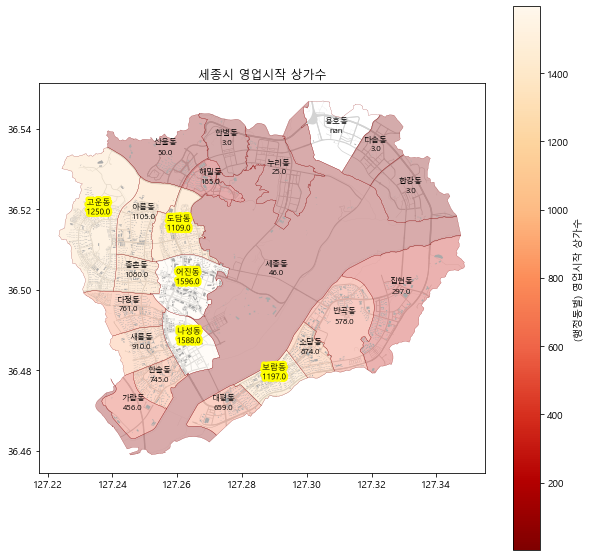

   행정동 이름  영업시작 상가수
9     어진동    1596.0
6     나성동    1588.0
11    고운동    1250.0
2     보람동    1197.0
13    도담동    1109.0


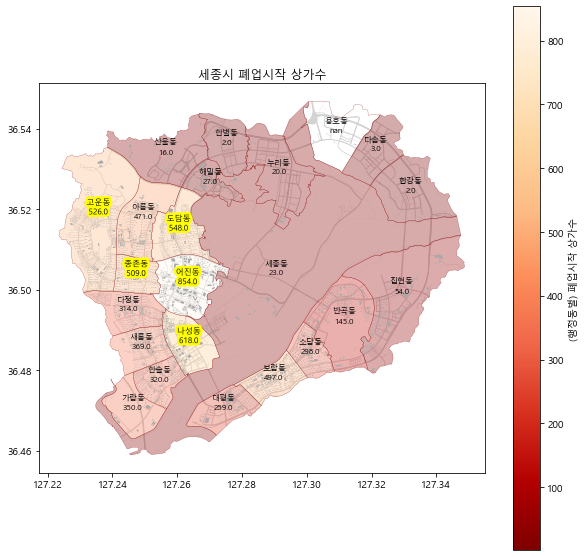

   행정동 이름  폐업시작 상가수
9     어진동     854.0
6     나성동     618.0
13    도담동     548.0
11    고운동     526.0
10    종촌동     509.0


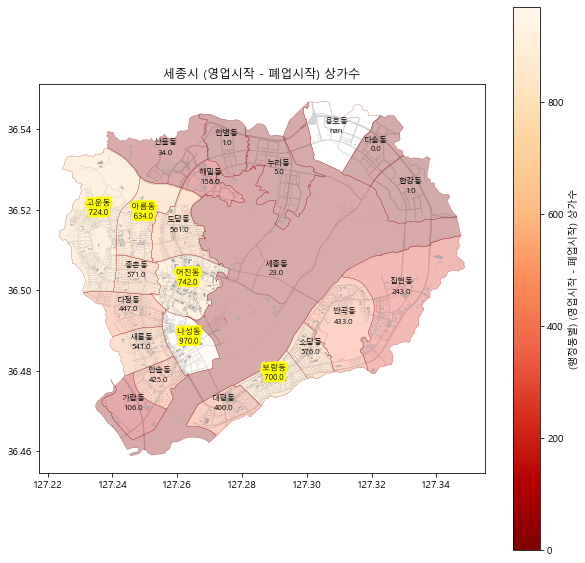

   행정동 이름  (영업시작 - 폐업시작) 상가수
6     나성동              970.0
9     어진동              742.0
11    고운동              724.0
2     보람동              700.0
12    아름동              634.0


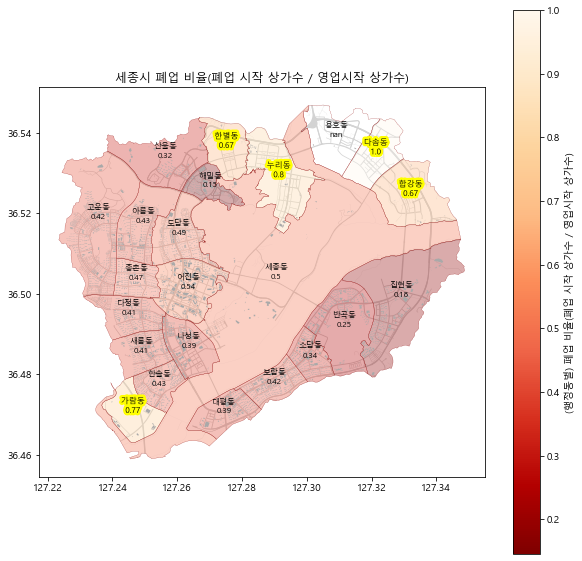

   행정동 이름  폐업 비율(폐업 시작 상가수 / 영업시작 상가수)
21    다솜동                     1.000000
19    누리동                     0.800000
4     가람동                     0.767544
16    합강동                     0.666667
20    한별동                     0.666667


In [65]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patheffects as path_effects

# 시각화 함수 정의
def visualize_sejong_data(column_name, title, cmap='OrRd_r'):
    # 세종시 경계
    sejong_zone_adm_gpd = sejong_zone_adm.copy()

    # 데이터프레임과 세종시 경계 데이터를 행정동 이름(EMD_NM) 기준으로 병합
    emd_counts_gdf = sejong_zone_adm_gpd.merge(emd_counts, left_on='EMD_NM', right_on='EMD_NM', how='left')

    # 해당 열(column_name) 기준 상위 5개 지역 추출
    top_5_areas = emd_counts_gdf.nlargest(5, column_name)

    # 시각화
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # 도로 데이터
    rw_poly_clipped.plot(ax=ax, facecolor='lightgrey', zorder=1)
    # 건물 데이터
    building_clipped.plot(ax=ax, facecolor='darkgrey', zorder=2)
    # 세종시 경계(기존 읍면동 단위)
    sejong_zone_adm_boundary.plot(ax=ax, facecolor='none', edgecolor='DarkRed', linewidth=0.2, zorder=3)

    # 행정동별 데이터 시각화
    emd_counts_gdf.plot(column=column_name, ax=ax, legend=True, cmap=cmap, alpha=0.33, 
                        legend_kwds={'label': f"(행정동별) {title}"})

    # 행정동별 이름과 데이터 값 표시
    for idx, row in emd_counts_gdf.iterrows():
        centroid = row['geometry'].centroid
        emd_name = row['EMD_NM']
        value = round(row[column_name], 2)  # 소수 둘째 자리까지 반올림
        
        # 형광펜 효과 설정 (상위 5개 지역에 대해 강조)
        if row['EMD_NM'] in top_5_areas['EMD_NM'].values:
            text = ax.annotate(text=f"{emd_name}\n{value}", xy=(centroid.x, centroid.y), 
                               ha='center', fontsize=8, color='black')
            text.set_path_effects([path_effects.Stroke(linewidth=5, foreground='yellow'),
                                   path_effects.Normal()])
        else:
            ax.annotate(text=f"{emd_name}\n{value}", xy=(centroid.x, centroid.y), 
                        ha='center', fontsize=8, color='black')

    plt.title(f"세종시 {title}")
    plt.show()

    # 상위 5개 지역에 대한 표 출력
    top_5_areas = top_5_areas[['EMD_NM', column_name]]
    top_5_areas.columns = ['행정동 이름', title]
    print(top_5_areas)

# lcpmt_dt 열을 시각화
visualize_sejong_data('lcpmt_dt', '영업시작 상가수')

# cls_date 열을 시각화
visualize_sejong_data('cls_date', '폐업시작 상가수')

# substract 열을 시각화
visualize_sejong_data('substract', '(영업시작 - 폐업시작) 상가수')

# close_ratio 열을 시각화
visualize_sejong_data('close_ratio', '폐업 비율(폐업 시작 상가수 / 영업시작 상가수)')


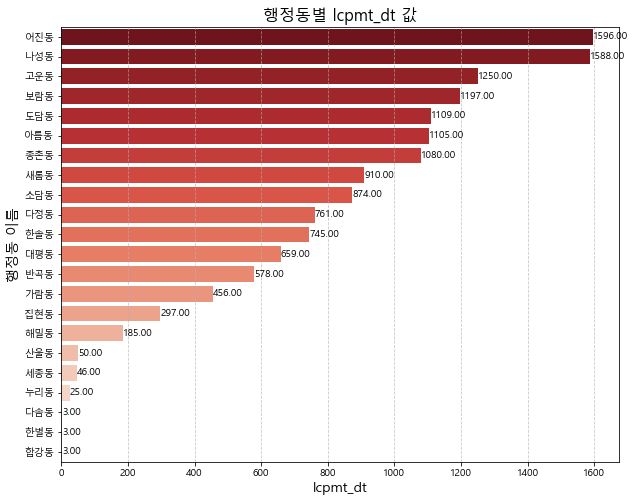

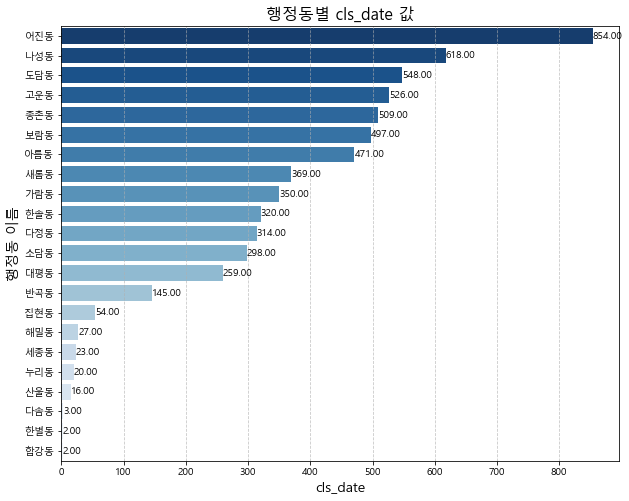

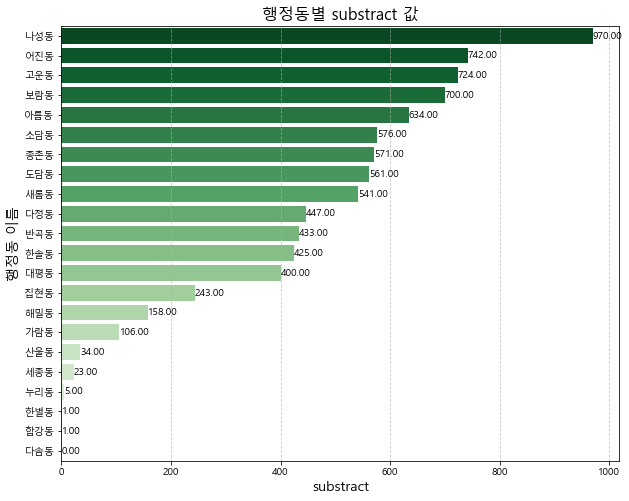

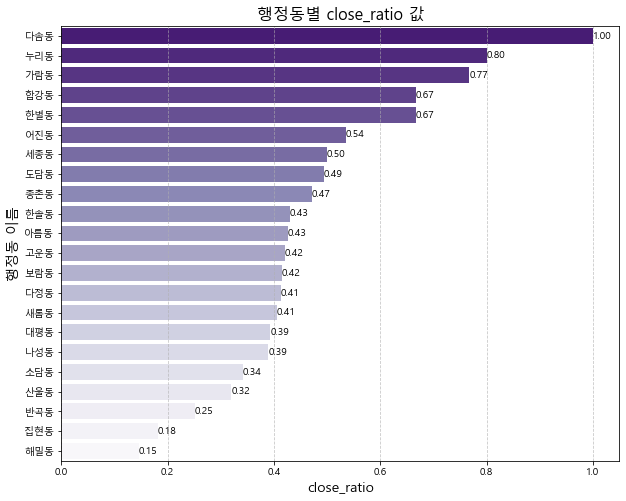

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터프레임 정의 (이 부분은 이미 주어졌다고 가정)
# emd_counts = pd.DataFrame({...})

# 시각화를 위한 컬러맵 설정
color_maps = ['Reds', 'Blues', 'Greens', 'Purples']

# 각 열에 대해 시각화
for i, column in enumerate(['lcpmt_dt', 'cls_date', 'substract', 'close_ratio']):
    # 데이터프레임을 내림차순으로 정렬
    sorted_df = emd_counts.sort_values(by=column, ascending=False)
    
    # 컬러맵을 거꾸로 적용
    colors = sns.color_palette(color_maps[i], len(sorted_df))[::-1]
    
    # 막대 그래프 생성
    plt.figure(figsize=(10, 8))
    barplot = sns.barplot(x=column, y='EMD_NM', data=sorted_df, palette=colors)
    
    # 막대마다 값 표기
    for index, value in enumerate(sorted_df[column]):
        plt.text(value, index, f'{value:.2f}', color='black', va="center", ha="left", fontsize=10)

    # 그래프 제목 및 라벨 설정
    plt.title(f'행정동별 {column} 값', fontsize=16)
    plt.xlabel(column, fontsize=14)
    plt.ylabel('행정동 이름', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # 그래프 표시
    plt.show()


## 2.2.3. (행정동별_업종별) 상가 "개수" 현황 ('영업/정상'과 '폐업' 상가 각각 파악)

In [85]:
# 데이터 복제: 업종 대분류 / 중분류 / 소분류 / 세종시 경계 각각 복제
zone_sanga_op_emd_mjr = zone_sanga_total_op.copy()
zone_sanga_op_emd_grp = zone_sanga_total_op.copy()
zone_sanga_op_emd_srv = zone_sanga_total_op.copy()

zone_sanga_cl_emd_mjr = zone_sanga_cl.copy()
zone_sanga_cl_emd_grp = zone_sanga_cl.copy()
zone_sanga_cl_emd_srv = zone_sanga_cl.copy()

sejong_zone_adm_gpd = sejong_zone_adm.copy()

### 2.2.3.1. (행정동별_업종별) 영업 시작 상가

#### # 대분류(major)

In [86]:
zone_sanga_op_emd_mjr

,EMD_CD,COL_ADM_SE,EMD_NM,major,group,service_nm,lcpmt_dt,biz_stts_cd,biz_stts_nm,cls_date,plc_area,zip_cd,addr,rd_addr,rd_zip_cd,bplc_nm,biz_type,lon,lat,geometry,index_right
0,36110102,36110,소담동,생활,유통,통신판매업,2012-01-10,1,영업/정상,NaT,NaN,NaN,세종특별자치시 소담동 *** 법조타운B,세종특별자치시 한누리대로 **** 법조타운B *층 ***호 (소담동),30147,(주)마랑,의류/패션/잡화/뷰티,127.302033,36.489279,POINT (127.30203 36.48928),1
1,36110104,36110,대평동,생활,미용,미용업,2012-01-17,1,영업/정상,NaT,33.57,339-005,세종특별자치시 대평동 668 해들마을 6단지 상가동,세종특별자치시 한누리대로 2236 해들마을 6단지 상가동 2층 C222호 (대평동),NaN,주미 에스테틱,피부미용업,127.278462,36.474994,POINT (127.27846 36.47499),3
2,36110107,36110,나성동,기타,사무지원,유료직업소개소,2012-01-19,1,영업/정상,NaT,NaN,NaN,세종특별자치시 나성동 752 한림프라자,세종특별자치시 한누리대로 219 한림프라자 4층 401 402호 (나성동),30127,(주)지에스씨넷,NaN,127.258974,36.484214,POINT (127.25897 36.48421),6
3,36110112,36110,고운동,생활,유통,통신판매업,2012-02-01,1,영업/정상,NaT,NaN,NaN,세종특별자치시 고운동 **** 금화빌딩,세종특별자치시 고운서길 ** 금화빌딩 *층 ***호 (고운동),30063,주식회사 아이키디아,교육/도서/완구/오락 가구/수납용품 건강/식품 의류/패션/잡화/뷰티,127.234925,36.505729,POINT (127.23493 36.50573),11
4,36110106,36110,한솔동,식품,음식점,일반음식점,2012-02-14,1,영업/정상,NaT,37.00,339-014,세종특별자치시 한솔동 940 첫마을2단지 110호,세종특별자치시 노을3로 19 상가동 110호 (한솔동 첫마을2단지),NaN,압구정 김밥,김밥(도시락),127.259840,36.481451,POINT (127.25984 36.48145),5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22460,36110111,36110,종촌동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-23,3,폐업,2024-05-30,NaN,339-013,세종특별자치시 종촌동 661 스마트빌딩,세종특별자치시 도움3로 105-6 스마트빌딩 1층 이마트에브리데이 세종종촌점 (종촌동),NaN,김찬길 명인 핫바,즉석판매제조가공업,127.249047,36.504569,POINT (127.24905 36.50457),10
22461,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-26,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 (나성동),NaN,달빛제유소,즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22462,36110107,36110,나성동,식품,식품 제조/가공/판매,즉석판매제조가공업,2024-05-24,3,폐업,2024-05-25,NaN,339-003,세종특별자치시 나성동 248,세종특별자치시 어울누리로 30 도시상징광장 (나성동),NaN,주식회사 세종시한글빵(단비캐릭터 솜사탕),즉석판매제조가공업,127.264220,36.486289,POINT (127.26422 36.48629),6
22463,36110106,36110,한솔동,건강,의료기기,의료기기판매(임대)업,2024-05-28,3,폐업,2024-06-04,NaN,NaN,세종특별자치시 한솔동 *** 첫마을*단지,세종특별자치시 나리로 ** 상가동 지*층 비***호 (한솔동 첫마을*단지),30130,지에스25 세종래미안점,NaN,127.256030,36.473031,POINT (127.25603 36.47303),5


In [87]:
import pandas as pd

# 데이터프레임을 groupby를 통해 EMD_NM 별로 major 열의 고유값들을 집계
grouped_op_emd_mjr = zone_sanga_op_emd_mjr.groupby('EMD_NM')['major'].value_counts().unstack(fill_value=0)
grouped_op_emd_mjr.reset_index(inplace=True)
# grouped.set_index('major')

# 업종별 총합 계산하여 Total 열 추가
grouped_op_emd_mjr['Total_mjr'] = grouped_op_emd_mjr[['건강', '기타', '동물', '문화', '생활', '식품', '자원환경']].sum(axis=1)

# total_counts의 총합 계산
grouped_op_emd_mjr_sum = grouped_op_emd_mjr[['건강','기타','동물','문화','생활','식품','자원환경','Total_mjr']].sum()

# 총합을 새로운 행으로 추가
grouped_op_emd_mjr.loc[len(grouped_op_emd_mjr)] = ['Total'] + grouped_op_emd_mjr_sum.tolist()

grouped_op_emd_mjr

major,EMD_NM,건강,기타,동물,문화,생활,식품,자원환경,Total_mjr
0,가람동,5,1,2,3,10,557,11,589
1,고운동,104,110,22,30,928,724,16,1934
2,나성동,222,164,36,108,909,1595,67,3101
3,누리동,0,3,0,0,0,19,6,28
4,다솜동,0,0,0,0,0,2,1,3
5,다정동,66,57,15,2,516,402,7,1065
6,대평동,62,54,14,14,300,427,17,888
7,도담동,101,84,21,47,500,762,25,1540
8,반곡동,53,44,7,5,366,278,10,763
9,보람동,87,87,17,45,650,907,27,1820


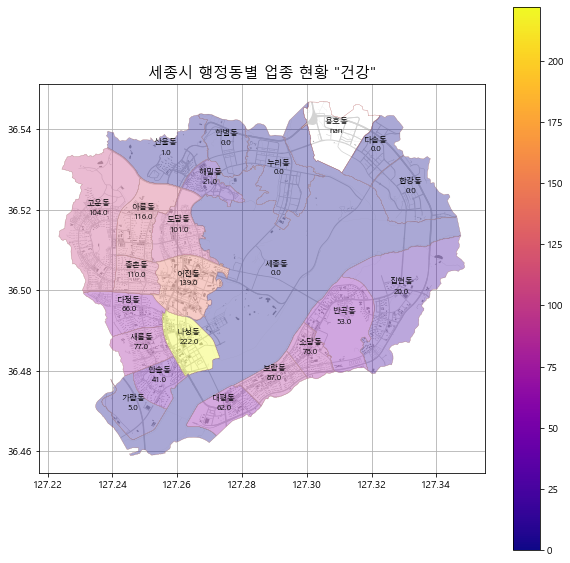

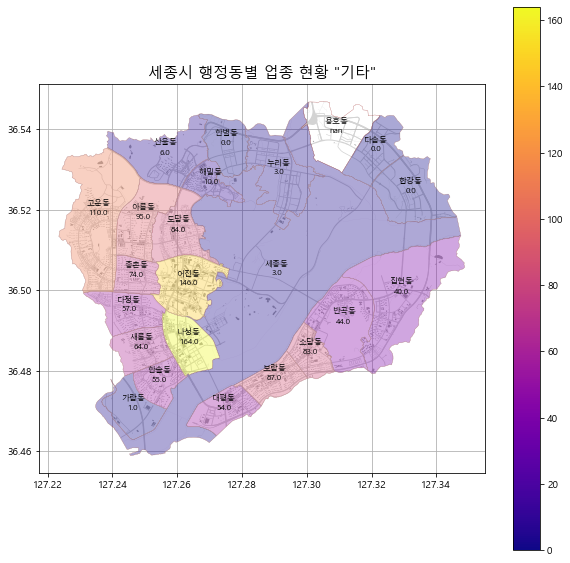

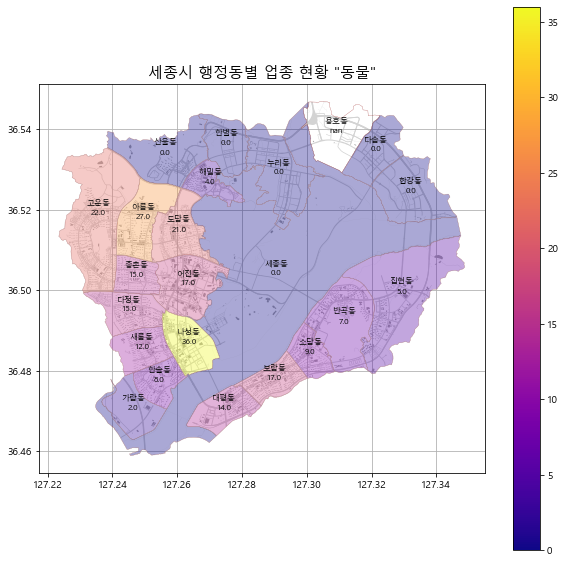

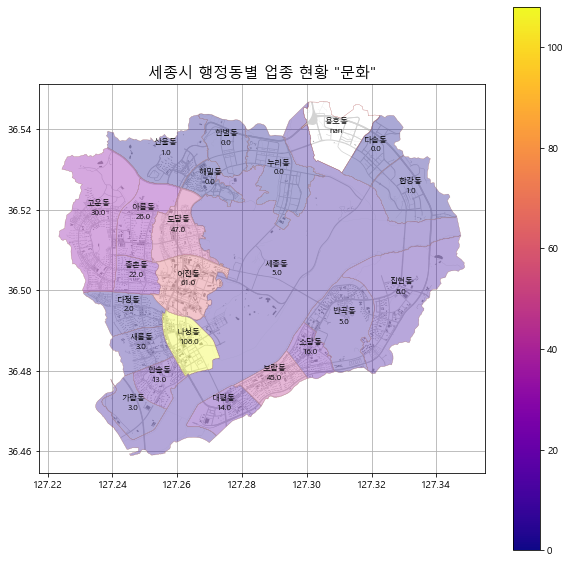

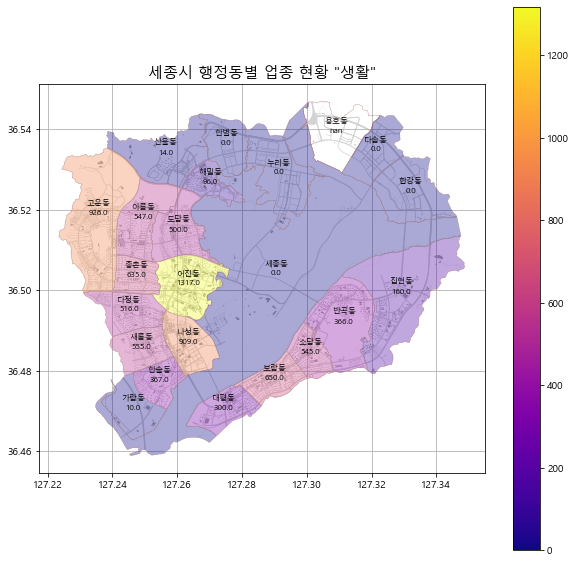

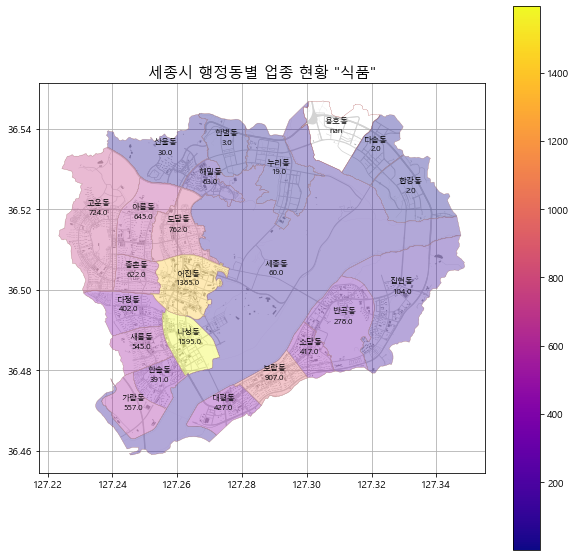

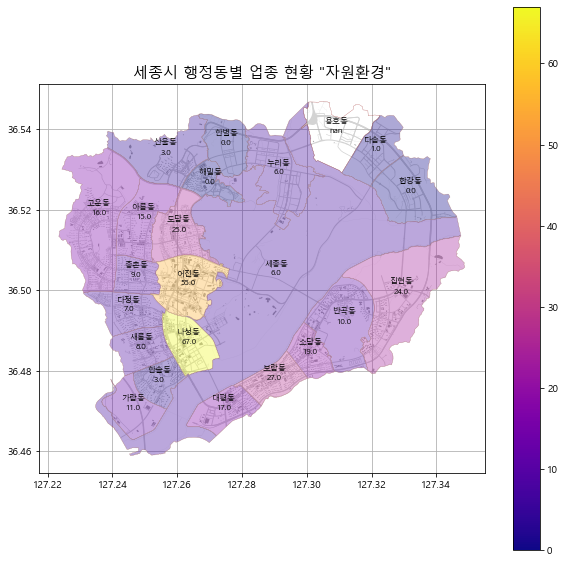

In [98]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# grouped_op_emd_mjr 데이터프레임과 sejong_zone_adm_gpd 데이터프레임이 이미 존재한다고 가정합니다.
# 또한 rw_poly_clipped, building_clipped, sejong_zone_adm_boundary 데이터도 존재한다고 가정합니다.

# 1. "Total" 행 제거
grouped_op_emd_mjr = grouped_op_emd_mjr[grouped_op_emd_mjr['EMD_NM'] != 'Total']

# 2. 각 업종에 대해 시각화 수행
grouped_op_emd_mjr_industries = ['건강', '기타', '동물', '문화', '생활', '식품', '자원환경']

for industry in grouped_op_emd_mjr_industries:
    # 3. sejong_zone_adm_gpd와 grouped_op_emd_mjr 데이터를 행정동 이름을 기준으로 병합
    grouped_op_emd_mjr_merged_gdf = sejong_zone_adm_gpd.merge(grouped_op_emd_mjr[['EMD_NM', industry]], how='left', left_on='EMD_NM', right_on='EMD_NM')
    
    # 4. 지도 시각화
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # 도로 데이터
    rw_poly_clipped.plot(ax=ax, facecolor='lightgrey', zorder=1)
    # 건물 데이터
    building_clipped.plot(ax=ax, facecolor='darkgrey', zorder=2)
    # 세종시 경계(기존 읍면동 단위)
    sejong_zone_adm_boundary.plot(ax=ax, facecolor='none', edgecolor='DarkRed', linewidth=0.2, zorder=3)

    # 업종별 데이터 시각화
    grouped_op_emd_mjr_merged_gdf.plot(column=industry, cmap='plasma', linewidth=0.8, ax=ax, edgecolor='0.8', alpha=0.35, legend=True, zorder=4)
    
    # 행정동 이름과 값 표시
    for x, y, label, value in zip(grouped_op_emd_mjr_merged_gdf.geometry.centroid.x, 
                                  grouped_op_emd_mjr_merged_gdf.geometry.centroid.y, 
                                  grouped_op_emd_mjr_merged_gdf['EMD_NM'], 
                                  grouped_op_emd_mjr_merged_gdf[industry]):
        ax.text(x, y, f'{label}\n{value}', fontsize=8, ha='center', color='black', zorder=5)

    # 그리드 추가
    ax.grid(True)
    
    ax.set_title(f'세종시 행정동별 업종 현황 "{industry}"', fontsize=15)
    ax.set_axis_on()

    # 5. 그래프 보여주기
    plt.show()

In [ ]:
# 'Total' 값을 제외한 grouped_op_emd_mjr 데이터프레임 필터링
grouped_op_emd_mjr_gdf = grouped_op_emd_mjr_gdf[grouped_op_emd_mjr_gdf['EMD_NM'] != 'Total']

# 지도 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
grouped_op_emd_mjr_gdf.plot(column='Total', cmap='Blues', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# 제목 설정
ax.set_title('Total 업종 수에 따른 세종시 행정동 분포', fontsize=15)
ax.axis('on')

plt.show()

In [80]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# grouped_op_emd_mjr와 sejong_zone_adm_gpd를 로드합니다.
# grouped_op_emd_mjr = pd.read_csv('path_to_grouped_op_emd_mjr.csv')  # 예시
# sejong_zone_adm_gpd = gpd.read_file('path_to_sejong_zone_adm_gpd.shp')  # 예시



# 필요한 열만 선택합니다.
cols_to_sum = ['건강', '기타', '동물', '문화', '생활', '식품', '자원환경']
grouped_op_emd_mjr_filtered['Total'] = grouped_op_emd_mjr_filtered[cols_to_sum].sum(axis=1)

# grouped_op_emd_mjr_filtered를 sejong_zone_adm_gpd와 병합
merged_gdf = sejong_zone_adm_gpd.merge(grouped_op_emd_mjr_filtered, left_on='EMD_NM', right_on='EMD_NM')

# 지도 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged_gdf.plot(column='Total', cmap='Blues', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# 제목 설정
ax.set_title('Total 업종 수에 따른 세종시 행정동 분포', fontsize=15)
ax.axis('off')

plt.show()


major,EMD_NM,건강,기타,동물,문화,생활,식품,자원환경,Total_mjr,Total
0,가람동,5,1,2,3,10,557,11,589,589
1,고운동,104,110,22,30,928,724,16,1934,1934
2,나성동,222,164,36,108,909,1595,67,3101,3101
3,누리동,0,3,0,0,0,19,6,28,28
4,다솜동,0,0,0,0,0,2,1,3,3
5,다정동,66,57,15,2,516,402,7,1065,1065
6,대평동,62,54,14,14,300,427,17,888,888
7,도담동,101,84,21,47,500,762,25,1540,1540
8,반곡동,53,44,7,5,366,278,10,763,763
9,보람동,87,87,17,45,650,907,27,1820,1820


#### # 중분류(group)

In [57]:
zone_sanga_op_emd_grp['group'].unique()

array(['유통', '미용', '사무지원', '음식점', '급식', '식품 제조/가공/판매', '미디어', '환경관리',
       '체육', '의료기관', '동물', '의료기기', '세탁소/빨래방', '에너지', '담배', '노래방', '여행',
       '문화기획', '게임', '이용', '관광', '비디오', '숙박', '영화', '축산', '목욕탕/찜질방/사우나',
       '민방위', '목재', '전문교육기관', '엘리베이터', '물류', '공연', '음악', '지하수'],
      dtype=object)

In [58]:
import pandas as pd

# 데이터프레임을 groupby를 통해 EMD_NM 별로 group 열의 고유값들을 집계
grouped_op_emd_grp = zone_sanga_op_emd_grp.groupby('EMD_NM')['group'].value_counts().unstack(fill_value=0)
grouped_op_emd_grp.reset_index(inplace=True)
# grouped.set_index('major')

# 업종별 총합 계산하여 Total 열 추가
grouped_op_emd_grp['Total_grp'] = grouped_op_emd_grp[['유통', '미용', '사무지원', '음식점', '급식', '식품 제조/가공/판매', '미디어', '환경관리',
       '체육', '의료기관', '동물', '의료기기', '세탁소/빨래방', '에너지', '담배', '노래방', '여행',
       '문화기획', '게임', '이용', '관광', '비디오', '숙박', '영화', '축산', '목욕탕/찜질방/사우나',
       '민방위', '목재', '전문교육기관', '엘리베이터', '물류', '공연', '음악', '지하수']].sum(axis=1)

# total_counts의 총합 계산
grouped_op_emd_grp_sum = grouped_op_emd_grp[['유통', '미용', '사무지원', '음식점', '급식', '식품 제조/가공/판매', '미디어', '환경관리',
       '체육', '의료기관', '동물', '의료기기', '세탁소/빨래방', '에너지', '담배', '노래방', '여행',
       '문화기획', '게임', '이용', '관광', '비디오', '숙박', '영화', '축산', '목욕탕/찜질방/사우나',
       '민방위', '목재', '전문교육기관', '엘리베이터', '물류', '공연', '음악', '지하수','Total_grp']].sum()

# 총합을 새로운 행으로 추가
grouped_op_emd_grp.loc[len(grouped_op_emd_grp)] = ['Total'] + grouped_op_emd_grp_sum.tolist()

grouped_op_emd_grp

group,EMD_NM,게임,공연,관광,급식,노래방,담배,동물,목욕탕/찜질방/사우나,목재,문화기획,물류,미디어,미용,민방위,비디오,사무지원,세탁소/빨래방,숙박,식품 제조/가공/판매,에너지,엘리베이터,여행,영화,유통,음식점,음악,의료기관,의료기기,이용,전문교육기관,지하수,체육,축산,환경관리,Total_grp
0,가람동,0,0,3,6,0,1,2,0,0,0,0,0,5,0,0,0,0,0,519,6,0,0,0,4,32,0,2,3,1,0,0,0,0,5,589
1,고운동,3,0,5,28,6,76,19,0,0,2,0,31,109,0,7,2,6,1,257,1,0,5,1,777,439,0,59,45,4,1,0,32,3,15,1934
2,나성동,31,1,2,25,22,102,30,3,0,7,2,40,207,1,21,15,2,1,476,3,3,17,6,649,1094,0,124,98,7,1,0,41,6,64,3101
3,누리동,0,0,0,7,0,2,0,0,0,0,0,0,0,0,0,0,0,0,8,1,0,0,0,0,4,0,0,0,0,1,0,0,0,5,28
4,다솜동,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,3
5,다정동,0,0,1,21,0,41,15,0,0,0,0,15,51,1,0,0,2,0,187,4,0,1,0,444,194,0,40,26,1,0,0,18,0,3,1065
6,대평동,3,0,3,25,0,37,14,0,0,1,0,13,47,1,2,2,1,0,178,5,1,2,3,236,224,0,40,22,3,0,0,13,0,12,888
7,도담동,19,0,1,29,17,63,18,0,1,1,0,18,75,0,2,1,4,0,152,8,0,7,0,395,581,0,61,40,2,2,0,24,3,16,1540
8,반곡동,0,1,0,32,0,29,7,0,0,1,0,13,17,0,0,2,0,0,70,1,0,3,0,336,176,0,28,25,1,0,0,12,0,9,763
9,보람동,13,0,6,26,10,47,13,0,1,1,0,33,94,1,5,4,0,0,202,3,0,10,0,521,679,0,44,43,2,2,0,33,4,23,1820


In [71]:
# 데이터프레임과 세종시 경계 데이터를 행정동 이름(EMD_NM) 기준으로 병합
grouped_op_emd_grp_gdf = sejong_zone_adm_gpd.merge(grouped_op_emd_grp, left_on='EMD_NM', right_on='EMD_NM', how='left')
grouped_op_emd_grp_gdf

EMD_CD COL_ADM_SE EMD_NM  \
0   36110101      36110    반곡동   
1   36110102      36110    소담동   
2   36110103      36110    보람동   
3   36110104      36110    대평동   
4   36110105      36110    가람동   
5   36110106      36110    한솔동   
6   36110107      36110    나성동   
7   36110108      36110    새롬동   
8   36110109      36110    다정동   
9   36110110      36110    어진동   
10  36110111      36110    종촌동   
11  36110112      36110    고운동   
12  36110113      36110    아름동   
13  36110114      36110    도담동   
14  36110115      36110    산울동   
15  36110116      36110    해밀동   
16  36110117      36110    합강동   
17  36110118      36110    집현동   
18  36110119      36110    세종동   
19  36110120      36110    누리동   
20  36110121      36110    한별동   
21  36110122      36110    다솜동   
22  36110123      36110    용호동   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

#### # 소분류(service_nm)

In [59]:
zone_sanga_op_emd_srv['service_nm'].unique()

array(['통신판매업', '미용업', '유료직업소개소', '일반음식점', '집단급식소', '제과점영업', '출판사',
       '축산판매업', '대기오염물질배출시설설치사업장', '체육도장업', '의원', '골프장', '동물병원', '안경업',
       '세탁업', '건강기능식품일반판매업', '약국', '인쇄사', '고압가스업', '부속의료기관', '식품자동판매기업',
       '담배소매업', '즉석판매제조가공업', '노래연습장업', '휴게음식점', '산후조리업', '안전상비의약품 판매업소',
       '수질오염원설치시설(기타)', '유통전문판매업', '국내외여행업', '후원방문판매업체', '문화예술법인', '당구장업',
       '건물위생관리업', '골프연습장업', '대규모점포', '소독업', '식품판매업(기타)', '의료기기판매(임대)업',
       '동물판매업', '인터넷컴퓨터게임시설제공업', '위탁급식영업', '이용업', '석유판매업', '치과기공소',
       '유원시설업(기타)', '비디오물제작업', '체력단련장업', '자동차야영장업', '옥외광고업', '종합체육시설업',
       '숙박업', '방문판매업', '영화상영관', '사료제조업', '종합여행업', '국내여행업', '목욕장업',
       '배출가스전문정비사업자(확인검사대행자)', '전력기술설계업체', '동물약국', '수영장업', '환경전문공사업',
       '국제회의기획업', '집단급식소식품판매업', '민방위급수시설', '청소년게임제공업', '제재업', '복합유통게임제공업',
       '요양보호사교육기관', '식품제조가공업', '식품소분업', '개인하수처리시설관리업(사업장)', '영화제작업',
       '저수조청소업', '병원', '승강기유지관리업체', '한옥체험업', '목재수입유통업', '전력기술감리업체',
       '동물미용업', '특정고압가스업', '무료직업소개소', '게임물제작업', '일반야영장업', '원목생산업', '의료법인',
   

In [60]:
import pandas as pd
grouped_op_emd_grp
# 데이터프레임을 groupby를 통해 EMD_NM 별로 service_nm 열의 고유값들을 집계
grouped_op_emd_srv = zone_sanga_op_emd_srv.groupby('EMD_NM')['service_nm'].value_counts().unstack(fill_value=0)
grouped_op_emd_srv.reset_index(inplace=True)
# grouped.set_index('major')

# 업종별 총합 계산하여 Total 열 추가
grouped_op_emd_srv['Total_srv'] = grouped_op_emd_srv[['통신판매업', '미용업', '유료직업소개소', '일반음식점', '집단급식소', '제과점영업', '출판사',
       '축산판매업', '대기오염물질배출시설설치사업장', '체육도장업', '의원', '골프장', '동물병원', '안경업',
       '세탁업', '건강기능식품일반판매업', '약국', '인쇄사', '고압가스업', '부속의료기관', '식품자동판매기업',
       '담배소매업', '즉석판매제조가공업', '노래연습장업', '휴게음식점', '산후조리업', '안전상비의약품 판매업소',
       '수질오염원설치시설(기타)', '유통전문판매업', '국내외여행업', '후원방문판매업체', '문화예술법인', '당구장업',
       '건물위생관리업', '골프연습장업', '대규모점포', '소독업', '식품판매업(기타)', '의료기기판매(임대)업',
       '동물판매업', '인터넷컴퓨터게임시설제공업', '위탁급식영업', '이용업', '석유판매업', '치과기공소',
       '유원시설업(기타)', '비디오물제작업', '체력단련장업', '자동차야영장업', '옥외광고업', '종합체육시설업',
       '숙박업', '방문판매업', '영화상영관', '사료제조업', '종합여행업', '국내여행업', '목욕장업',
       '배출가스전문정비사업자(확인검사대행자)', '전력기술설계업체', '동물약국', '수영장업', '환경전문공사업',
       '국제회의기획업', '집단급식소식품판매업', '민방위급수시설', '청소년게임제공업', '제재업', '복합유통게임제공업',
       '요양보호사교육기관', '식품제조가공업', '식품소분업', '개인하수처리시설관리업(사업장)', '영화제작업',
       '저수조청소업', '병원', '승강기유지관리업체', '한옥체험업', '목재수입유통업', '전력기술감리업체',
       '동물미용업', '특정고압가스업', '무료직업소개소', '게임물제작업', '일반야영장업', '원목생산업', '의료법인',
       '국제물류주선업', '동물위탁관리업', '의료유사업', '쓰레기종량제봉투판매업', '공연장', '건설폐기물처리업',
       '음반.음악영상물배급업', '건강기능식품유통전문판매업', '의료기기수리업', '지하수영향조사기관', '식품첨가물제조업',
       '전화권유판매업', '동물전시업', '대중문화예술기획업', '동물용의료용구판매업', '지하수시공업체',
       '음반.음악영상물제작업', '시내순환관광업', '관광숙박업', '환경컨설팅회사', '빙상장업', '식품운반업',
       '가축인공수정소', '동물운송업', '게임물배급업', '동물용의약품도매상', '환경관리대행기관', '환경측정대행업',
       '축산가공업', '용기·포장지제조업', '가축사육업', '식육포장처리업', '영화상영업', '외국인관광도시민박업',
       '썰매장업', '일반유원시설업']].sum(axis=1)

# total_counts의 총합 계산
grouped_op_emd_srv_sum = grouped_op_emd_srv[['통신판매업', '미용업', '유료직업소개소', '일반음식점', '집단급식소', '제과점영업', '출판사',
       '축산판매업', '대기오염물질배출시설설치사업장', '체육도장업', '의원', '골프장', '동물병원', '안경업',
       '세탁업', '건강기능식품일반판매업', '약국', '인쇄사', '고압가스업', '부속의료기관', '식품자동판매기업',
       '담배소매업', '즉석판매제조가공업', '노래연습장업', '휴게음식점', '산후조리업', '안전상비의약품 판매업소',
       '수질오염원설치시설(기타)', '유통전문판매업', '국내외여행업', '후원방문판매업체', '문화예술법인', '당구장업',
       '건물위생관리업', '골프연습장업', '대규모점포', '소독업', '식품판매업(기타)', '의료기기판매(임대)업',
       '동물판매업', '인터넷컴퓨터게임시설제공업', '위탁급식영업', '이용업', '석유판매업', '치과기공소',
       '유원시설업(기타)', '비디오물제작업', '체력단련장업', '자동차야영장업', '옥외광고업', '종합체육시설업',
       '숙박업', '방문판매업', '영화상영관', '사료제조업', '종합여행업', '국내여행업', '목욕장업',
       '배출가스전문정비사업자(확인검사대행자)', '전력기술설계업체', '동물약국', '수영장업', '환경전문공사업',
       '국제회의기획업', '집단급식소식품판매업', '민방위급수시설', '청소년게임제공업', '제재업', '복합유통게임제공업',
       '요양보호사교육기관', '식품제조가공업', '식품소분업', '개인하수처리시설관리업(사업장)', '영화제작업',
       '저수조청소업', '병원', '승강기유지관리업체', '한옥체험업', '목재수입유통업', '전력기술감리업체',
       '동물미용업', '특정고압가스업', '무료직업소개소', '게임물제작업', '일반야영장업', '원목생산업', '의료법인',
       '국제물류주선업', '동물위탁관리업', '의료유사업', '쓰레기종량제봉투판매업', '공연장', '건설폐기물처리업',
       '음반.음악영상물배급업', '건강기능식품유통전문판매업', '의료기기수리업', '지하수영향조사기관', '식품첨가물제조업',
       '전화권유판매업', '동물전시업', '대중문화예술기획업', '동물용의료용구판매업', '지하수시공업체',
       '음반.음악영상물제작업', '시내순환관광업', '관광숙박업', '환경컨설팅회사', '빙상장업', '식품운반업',
       '가축인공수정소', '동물운송업', '게임물배급업', '동물용의약품도매상', '환경관리대행기관', '환경측정대행업',
       '축산가공업', '용기·포장지제조업', '가축사육업', '식육포장처리업', '영화상영업', '외국인관광도시민박업',
       '썰매장업', '일반유원시설업','Total_srv']].sum()

# 총합을 새로운 행으로 추가
grouped_op_emd_srv.loc[len(grouped_op_emd_srv)] = ['Total'] + grouped_op_emd_srv_sum.tolist()

grouped_op_emd_srv

service_nm,EMD_NM,가축사육업,가축인공수정소,개인하수처리시설관리업(사업장),건강기능식품유통전문판매업,건강기능식품일반판매업,건물위생관리업,건설폐기물처리업,게임물배급업,게임물제작업,고압가스업,골프연습장업,골프장,공연장,관광숙박업,국내여행업,국내외여행업,국제물류주선업,국제회의기획업,노래연습장업,담배소매업,당구장업,대규모점포,대기오염물질배출시설설치사업장,대중문화예술기획업,동물미용업,동물병원,동물약국,동물용의료용구판매업,동물용의약품도매상,동물운송업,동물위탁관리업,동물전시업,동물판매업,목욕장업,목재수입유통업,무료직업소개소,문화예술법인,미용업,민방위급수시설,방문판매업,배출가스전문정비사업자(확인검사대행자),병원,복합유통게임제공업,부속의료기관,비디오물제작업,빙상장업,사료제조업,산후조리업,석유판매업,세탁업,소독업,수영장업,수질오염원설치시설(기타),숙박업,승강기유지관리업체,시내순환관광업,식육포장처리업,식품소분업,식품운반업,식품자동판매기업,식품제조가공업,식품첨가물제조업,식품판매업(기타),썰매장업,쓰레기종량제봉투판매업,안경업,안전상비의약품 판매업소,약국,영화상영관,영화상영업,영화제작업,옥외광고업,외국인관광도시민박업,요양보호사교육기관,용기·포장지제조업,원목생산업,위탁급식영업,유료직업소개소,유원시설업(기타),유통전문판매업,음반.음악영상물배급업,음반.음악영상물제작업,의료기기수리업,의료기기판매(임대)업,의료법인,의료유사업,의원,이용업,인쇄사,인터넷컴퓨터게임시설제공업,일반야영장업,일반유원시설업,일반음식점,자동차야영장업,저수조청소업,전력기술감리업체,전력기술설계업체,전화권유판매업,제과점영업,제재업,종합여행업,종합체육시설업,즉석판매제조가공업,지하수시공업체,지하수영향조사기관,집단급식소,집단급식소식품판매업,청소년게임제공업,체력단련장업,체육도장업,축산가공업,축산판매업,출판사,치과기공소,통신판매업,특정고압가스업,한옥체험업,환경관리대행기관,환경전문공사업,환경측정대행업,환경컨설팅회사,후원방문판매업체,휴게음식점,Total_srv
0,가람동,0,0,0,0,6,0,0,0,0,5,0,0,0,0,0,0,0,0,0,1,0,0,3,0,0,0,1,0,0,0,0,0,1,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,4,0,3,0,0,0,0,3,0,0,1,1,0,0,0,0,11,0,0,0,0,0,2,0,0,0,508,0,0,2,0,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,21,589
1,고운동,0,0,0,0,105,6,0,0,0,0,2,0,0,0,0,2,0,0,6,76,1,0,0,0,1,1,11,1,0,0,3,1,1,0,0,0,2,109,0,2,0,0,0,0,7,0,3,2,1,6,5,0,3,0,0,0,0,2,0,16,3,0,3,0,1,3,22,15,0,0,1,3,0,1,0,0,0,2,5,1,0,0,0,41,0,0,20,4,3,2,0,0,310,0,0,0,0,1,23,0,3,0,94,0,0,28,1,1,8,21,1,8,25,1,763,0,1,0,0,0,0,11,129,1934
2,나성동,0,0,0,4,70,28,0,1,3,1,9,0,1,0,1,6,2,3,22,102,6,0,0,3,6,4,14,2,1,0,1,0,2,3,0,1,1,207,1,6,0,3,5,0,21,1,6,1,0,2,22,0,5,0,3,0,0,6,0,28,3,0,1,1,0,7,23,29,5,0,1,8,1,1,0,0,6,14,2,16,0,0,1,85,1,1,66,7,3,16,0,0,900,0,7,1,1,0,21,0,10,0,316,0,0,19,1,6,15,9,0,10,29,5,642,0,0,0,1,1,0,1,194,3101
3,누리동,0,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28
4,다솜동,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
5,다정동,0,0,0,0,60,0,0,0,0,1,0,0,0,0,0,1,0,0,0,41,0,0,0,0,4,2,8,1,0,0,0,0,0,0,0,0,0,51,1,4,0,0,0,0,0,0,0,0,3,2,0,1,3,0,0,0,0,3,0,10,0,0,1,0,0,3,8,7,0,0,0,0,0,0,0,0,0,0,1,3,0,0,0,23,0,0,25,1,0,0,0,0,145,0,0,0,0,0,11,0,0,0,94,0,0,21,0,0,3,14,0,5,15,0,437,0,0,0,0,0,0,3,49,1065
6,대평동,0,0,0,1,37,4,0,0,0,3,3,0,0,0,1,1,0,0,0,37,2,2,0,0,5,2,5,1,0,0,1,0,0,0,0,0,1,47,1,2,1,9,0,0,2,0,0,3,2,1,4,1,3,0,1,0,0,2,0,11,1,0,1,0,0,3,6,7,2,1,0,2,0,0,0,0,8,2,3,3,0,0,1,17,0,0,15,3,0,3,0,0,167,0,0,0,0,0,8,0,0,0,109,0,0,17,0,0,3,4,0,5,11,1,230,0,0,0,0,0,0,2,57,888
7,도담동,0,0,1,0,51,6,0,0,0,4,1,0,0,0,4,3,0,0,17,63,5,0,1,0,5,3,7,1,0,1,1,0,0,0,0,0,1,75,0,1,0,1,5,0,2,0,3,0,2,4,2,0,5,0,0,0,0,2,1,6,2,1,2,0,0,4,17,23,0,0,0,0,0,2,0,1,1,1,1,2,0,0,2,33,0,0,20,2,2,8,0,0,474,0,1,0,0,0,10,0,0,0,64,0,0,28,0,6,8,10,0,11,16,1,393,2,0,0,0,0,0,1,107,1540
8,반곡동,0,0,0,1,31,4,0,0,0,0,1,0,1,0,1,1,0,0,0,29,0,0,0,0,1,1,4,0,0,0,1,0,0,0,0,0,1,17,0,2,0,1,0,0,0,0,0,0,1,0,3,1,1,0,0,0,0,2,0,10,0,0,0,0,0,3,6,6,0,0,0,0,0,0,0,0,10,2,0,3,0,0,0,21,0,0,15,1,2,0,0,0,111,0,1,0,0,0,5,0,1,0,16,0,0,22,0,0,2,8,0,2,11,1,332,0,0,0,0,0,0,2,65,763
9,보람동,0,0,0,1,55,14,0,0,0,3,4,0,0,0,1,3,0,0,10,47,2,1,1,0,2,1,6,2,0,1,1,0,0,0,0,1,1,94,1,1,0,0,1,0,5,1,4,1,0,0,4,2,1,0,0,1,0,6,0,24,1,0,0,0,0,2,12,9,0,0,0,5,0,2,0,0,1,3,5,7,0,0,0,40,0,0,22,2,2,10,0,0,520,0,3,0,0,0,12,1,6,0,89,0,0,25,0,2,9,15,0,7,26,1,517,0,0,0,0,0,0,2,159,1820


In [72]:
# 데이터프레임과 세종시 경계 데이터를 행정동 이름(EMD_NM) 기준으로 병합
grouped_op_emd_srv_gdf = sejong_zone_adm_gpd.merge(grouped_op_emd_srv, left_on='EMD_NM', right_on='EMD_NM', how='left')
grouped_op_emd_srv_gdf

EMD_CD COL_ADM_SE EMD_NM  \
0   36110101      36110    반곡동   
1   36110102      36110    소담동   
2   36110103      36110    보람동   
3   36110104      36110    대평동   
4   36110105      36110    가람동   
5   36110106      36110    한솔동   
6   36110107      36110    나성동   
7   36110108      36110    새롬동   
8   36110109      36110    다정동   
9   36110110      36110    어진동   
10  36110111      36110    종촌동   
11  36110112      36110    고운동   
12  36110113      36110    아름동   
13  36110114      36110    도담동   
14  36110115      36110    산울동   
15  36110116      36110    해밀동   
16  36110117      36110    합강동   
17  36110118      36110    집현동   
18  36110119      36110    세종동   
19  36110120      36110    누리동   
20  36110121      36110    한별동   
21  36110122      36110    다솜동   
22  36110123      36110    용호동   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

# 여기까지 한 것 => 금요일까지 한 작업

## 2.2.4. (업종별) 상가 "개수" 현황 ('영업/정상'과 '폐업' 상가 각각 파악)

### 2.2.4.1. "major(대분류)" 기준 업종별 분류

In [ ]:
# 데이터 복사
zone_sanga_cl_mjr = zone_sanga_cl.copy()
zone_sanga_op_mjr = zone_sanga_op.copy()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. lcpmt_dt 열을 datetime 형식으로 변환
zone_sanga_cl_mjr['lcpmt_dt'] = pd.to_datetime(zone_sanga_cl_mjr['lcpmt_dt'])
zone_sanga_cl_mjr['cls_date'] = pd.to_datetime(zone_sanga_cl_mjr['cls_date'])
zone_sanga_op_mjr['lcpmt_dt'] = pd.to_datetime(zone_sanga_op_mjr['lcpmt_dt'])

# 2. service_nm 열에서 겹치는 고유값들만 남기고 나머지 제거
zone_sanga_mjr_all = set(zone_sanga_cl_mjr['major'].unique()) & set(zone_sanga_op_mjr['major'].unique())

zone_sanga_cl_mjr = zone_sanga_cl_mjr[zone_sanga_cl_mjr['major'].isin(zone_sanga_mjr_all)]
zone_sanga_op_mjr = zone_sanga_op_mjr[zone_sanga_op_mjr['major'].isin(zone_sanga_mjr_all)]

# 3. service_nm 열 내 고유값들의 개수 세고 오름차순으로 정리
zone_sanga_mjr_closed_service_counts = zone_sanga_cl_mjr['major'].value_counts().sort_index()
zone_sanga_mjr_open_service_counts = zone_sanga_op_mjr['major'].value_counts().sort_index()

print("'폐업 상가' 업종별(대분류) 집계:")
print(zone_sanga_mjr_closed_service_counts)

print("'영업 상가' 업종별(대분류) 집계:")
print(zone_sanga_mjr_open_service_counts)

# 4. lcpmt_dt 열 기준으로 월단위 시계열 groupby 후 service_nm 별로 집계
zone_sanga_mjr_cl_op_grp = zone_sanga_cl_mjr.groupby([pd.Grouper(key='lcpmt_dt', freq='M'), 'major']).size().unstack(fill_value=0)
zone_sanga_mjr_cl_cl_grp = zone_sanga_cl_mjr.groupby([pd.Grouper(key='cls_date', freq='M'), 'major']).size().unstack(fill_value=0)
zone_sanga_mjr_op_grp = zone_sanga_op_mjr.groupby([pd.Grouper(key='lcpmt_dt', freq='M'), 'major']).size().unstack(fill_value=0)

In [ ]:
zone_sanga_mjr_cl_op_grp

In [ ]:
zone_sanga_mjr_cl_cl_grp

In [ ]:
zone_sanga_mjr_op_grp

#### # 업종별 연도별 집계

In [ ]:
# 날짜를 연도로 변환하는 새로운 열을 생성
zone_sanga_mjr_cl_op_grp.reset_index(inplace=True)
zone_sanga_mjr_cl_cl_grp.reset_index(inplace=True)
zone_sanga_mjr_op_grp.reset_index(inplace=True)

In [ ]:
import pandas as pd

# 날짜를 연도로 변환하는 새로운 열을 생성합니다.
zone_sanga_mjr_cl_op_grp['year'] = pd.to_datetime(zone_sanga_mjr_cl_op_grp['lcpmt_dt']).dt.year # 폐업 데이터 내 "영업" 상가(지정일자)
zone_sanga_mjr_cl_cl_grp['year'] = pd.to_datetime(zone_sanga_mjr_cl_cl_grp['cls_date']).dt.year # 폐업 데이터 내 "폐업" 상가(폐업일자)
zone_sanga_mjr_op_grp['year'] = pd.to_datetime(zone_sanga_mjr_op_grp['lcpmt_dt']).dt.year # 영업 데이터 내 "영업" 상가(지정일자)

# 연도별로 합계를 구합니다.
zone_sanga_mjr_cl_op_grp_yearly = zone_sanga_mjr_cl_op_grp.groupby('year').sum().reset_index()
zone_sanga_mjr_cl_cl_grp_yearly = zone_sanga_mjr_cl_cl_grp.groupby('year').sum().reset_index()
zone_sanga_mjr_op_grp_yearly = zone_sanga_mjr_op_grp.groupby('year').sum().reset_index()

# 연도별 데이터프레임 출력
print("zone_sanga_mjr_cl_op_grp_yearly:")
print(zone_sanga_mjr_cl_op_grp_yearly)

print("zone_sanga_mjr_cl_cl_grp_yearly:")
print(zone_sanga_mjr_cl_cl_grp_yearly)

print("zone_sanga_mjr_op_grp_yearly:")
print(zone_sanga_mjr_op_grp_yearly)


#### # 총 영업 상가 = 지정일자 기준 상가 (영업 데이터 상가 + 폐업 데이터 상가)

In [ ]:
# 데이터프레임들의 업종들에 대한 연도별 합계 집계
mjr_cl_op_grp_yearly_sums = zone_sanga_mjr_cl_op_grp_yearly.groupby('year').sum() # 폐업 데이터 내 "영업시작"
mjr_op_grp_yearly_sums = zone_sanga_mjr_op_grp_yearly.groupby('year').sum() # 영업 데이터 내 "영업시작"

# 집계된 데이터프레임을 연도별로 합침
zone_sanga_mjr_op_tot_grp_yearly = mjr_cl_op_grp_yearly_sums.add(mjr_op_grp_yearly_sums, fill_value=0)

# 결과 출력 또는 저장
print(zone_sanga_mjr_op_tot_grp_yearly)
# zone_sanga_mjr_op_tot_grp_yearly.to_csv('zone_sanga_mjr_op_tot_grp_yearly.csv')  # 필요한 경우 저장

#### # 폐업 상가수 현황 (연도별 추이)

In [ ]:
zone_sanga_mjr_cl_cl_grp_yearly

In [ ]:
# 데이터 복제
zone_sanga_mjr_cl_cl_grp_yearly_total = zone_sanga_mjr_cl_cl_grp_yearly.copy()

# 2012년 이후 데이터만 남기기 위한 필터링
zone_sanga_mjr_cl_cl_grp_yearly_total = zone_sanga_mjr_cl_cl_grp_yearly_total[zone_sanga_mjr_cl_cl_grp_yearly_total['year'] >= 2012]

zone_sanga_mjr_cl_cl_grp_yearly_total.reset_index(inplace=True)
zone_sanga_mjr_cl_cl_grp_yearly_total = zone_sanga_mjr_cl_cl_grp_yearly_total.drop(columns=['index'])
zone_sanga_mjr_cl_cl_grp_yearly_total

In [ ]:
# 업종별 총합 계산하여 Total 열 추가
zone_sanga_mjr_cl_cl_grp_yearly_total['Total'] = zone_sanga_mjr_cl_cl_grp_yearly_total[['건강', '기타', '동물', '문화', '생활', '식품', '자원환경']].sum(axis=1)

# total_counts의 총합 계산
zone_sanga_mjr_cl_cl_grp_yearly_total_sum = zone_sanga_mjr_cl_cl_grp_yearly_total[['건강','기타','동물','문화','생활','식품','자원환경','Total']].sum()

# 총합을 새로운 행으로 추가
zone_sanga_mjr_cl_cl_grp_yearly_total.loc[len(zone_sanga_mjr_cl_cl_grp_yearly_total)] = ['Total'] + zone_sanga_mjr_cl_cl_grp_yearly_total_sum.tolist()

zone_sanga_mjr_cl_cl_grp_yearly_total

#### # 총 영업 상가수 현황 (연도별 추이)

In [ ]:
zone_sanga_mjr_op_tot_grp_yearly

In [ ]:
zone_sanga_mjr_op_tot_grp_yearly.reset_index(inplace=True)
zone_sanga_mjr_op_tot_grp_yearly

In [ ]:
# 데이터 복제
zone_sanga_mjr_op_tot_grp_yearly_total = zone_sanga_mjr_op_tot_grp_yearly.copy()

# 2012년 이후 데이터만 남기기 위한 필터링
zone_sanga_mjr_op_tot_grp_yearly_total = zone_sanga_mjr_op_tot_grp_yearly_total[zone_sanga_mjr_op_tot_grp_yearly_total['year'] >= 2012]

zone_sanga_mjr_op_tot_grp_yearly_total.reset_index(inplace=True)
zone_sanga_mjr_op_tot_grp_yearly_total = zone_sanga_mjr_op_tot_grp_yearly_total.drop(columns=['index'])
zone_sanga_mjr_op_tot_grp_yearly_total

In [ ]:
# 업종별 총합 계산하여 Total 열 추가
zone_sanga_mjr_op_tot_grp_yearly_total['Total'] = zone_sanga_mjr_op_tot_grp_yearly_total[['건강', '기타', '동물', '문화', '생활', '식품', '자원환경']].sum(axis=1)

# total_counts의 총합 계산
zone_sanga_mjr_op_tot_grp_yearly_total_sum = zone_sanga_mjr_op_tot_grp_yearly_total[['건강','기타','동물','문화','생활','식품','자원환경','Total']].sum()

# 총합을 새로운 행으로 추가
zone_sanga_mjr_op_tot_grp_yearly_total.loc[len(zone_sanga_mjr_op_tot_grp_yearly_total)] = ['Total'] + zone_sanga_mjr_op_tot_grp_yearly_total_sum.tolist()

zone_sanga_mjr_op_tot_grp_yearly_total

#### # 폐업시작과 영업시작 상가수 Total 값 시각화

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Total 행만 추출
cl_total = zone_sanga_mjr_cl_cl_grp_yearly_total.iloc[-1, 1:]
op_total = zone_sanga_mjr_op_tot_grp_yearly_total.iloc[-1, 1:]

# 시각화
plt.figure(figsize=(10, 6))

plt.plot(cl_total.index, cl_total.values, marker='o', label='폐업 시작 상가수')
plt.plot(op_total.index, op_total.values, marker='o', label='영업 시작 상가수')

plt.title('업종별 영업 시작 및 폐업 시작 상가수 (Total)')
plt.xlabel('업종')
plt.ylabel('상가수')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Total 행만 추출
cl_total = zone_sanga_mjr_cl_cl_grp_yearly_total.iloc[-1, 1:]
op_total = zone_sanga_mjr_op_tot_grp_yearly_total.iloc[-1, 1:]

# 영업 시작 상가수 - 폐업 시작 상가수 계산
diff_total = op_total - cl_total

# 시각화
plt.figure(figsize=(10, 6))

# 막대그래프 그리기
bar_width = 0.35
index = cl_total.index

plt.bar(index, cl_total.values, bar_width, label='폐업 시작 상가수')
plt.bar(index, op_total.values, bar_width, bottom=cl_total.values, label='영업 시작 상가수')
plt.bar(index, diff_total.values, bar_width, bottom=(cl_total + op_total).values, label='영업 시작 - 폐업 시작')

# 그래프 설정
plt.title('업종별 영업 시작 및 폐업 시작 상가수 (Total)')
plt.xlabel('업종')
plt.ylabel('상가수')
plt.legend()
plt.grid(True, axis='y')

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Total 행만 추출
cl_total = zone_sanga_mjr_cl_cl_grp_yearly_total.iloc[-1, 1:]
op_total = zone_sanga_mjr_op_tot_grp_yearly_total.iloc[-1, 1:]

# 영업 시작 상가수 - 폐업 시작 상가수 계산
diff_total = op_total - cl_total

# 업종 전체의 합계 계산
cl_sum = cl_total.sum()
op_sum = op_total.sum()
diff_sum = diff_total.sum()

# 시각화
plt.figure(figsize=(14, 8))

# 막대그래프 그리기 - 업종별
bar_width = 0.35
index = cl_total.index

plt.bar(index, cl_total.values, bar_width, label='폐업 시작 상가수')
plt.bar(index, op_total.values, bar_width, bottom=cl_total.values, label='영업 시작 상가수')
plt.bar(index, diff_total.values, bar_width, bottom=(cl_total + op_total).values, label='영업 시작 - 폐업 시작')

# 막대그래프 그리기 - 전체 합계
plt.bar('전체 합계', cl_sum, bar_width, label='전체 폐업 시작 상가수', color='red')
plt.bar('전체 합계', op_sum, bar_width, bottom=cl_sum, label='전체 영업 시작 상가수', color='blue')
plt.bar('전체 합계', diff_sum, bar_width, bottom=(cl_sum + op_sum), label='전체 영업 시작 - 폐업 시작', color='green')

# 그래프 설정
plt.title('업종별 및 전체 영업 시작 및 폐업 시작 상가수 (Total)')
plt.xlabel('업종')
plt.ylabel('상가수')
plt.legend()
plt.grid(True, axis='y')

plt.show()


#### # 폐업시작과 영업시작 상가수 업종별 연도별 추이 시각화 (2012년~2024년)

In [ ]:
zone_sanga_mjr_cl_cl_grp_yearly_total

In [ ]:
zone_sanga_mjr_op_tot_grp_yearly_total

In [ ]:
# Total 행 제거
df_cl_yearly = zone_sanga_mjr_cl_cl_grp_yearly_total.iloc[:-1, :]
df_op_yearly = zone_sanga_mjr_op_tot_grp_yearly_total.iloc[:-1, :]

print(df_cl_yearly)
print(df_op_yearly)

In [ ]:
# 데이터 세팅 (2012년부터 2024년까지)
years = df_cl_yearly['year'].values  # Total 행 제거 후의 years 값 추출
columns = ['건강', '기타', '동물', '문화', '생활', '식품', '자원환경']

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 데이터 세팅 (2012년부터 2024년까지)
years = df_cl_yearly['year'].values  # Total 행 제거 후의 years 값 추출
columns = ['건강', '기타', '동물', '문화', '생활', '식품', '자원환경']

# 시각화 준비
plt.figure(figsize=(14, 8))

# 시각화 데이터 저장을 위한 리스트
lines = []
labels = []

for column in columns:
    line1, = plt.plot(years, df_cl_yearly[column], marker='o', linestyle='--', label=f'{column}-폐업')
    line2, = plt.plot(years, df_op_yearly[column], marker='o', label=f'{column}-영업')
    lines.extend([line1, line2])
    labels.extend([f'{column}-폐업', f'{column}-영업'])

# 범례를 값이 높은 순으로 정렬
sorted_lines_labels = sorted(zip(lines, labels), key=lambda x: max(x[0].get_ydata()), reverse=True)
sorted_lines, sorted_labels = zip(*sorted_lines_labels)

plt.legend(sorted_lines, sorted_labels, loc='best')  # 범례를 그래프 안에 배치하고, 'best' 위치를 자동 선택

# 그래프 설정
plt.title('업종별 영업시작 상가수와 폐업시작 상가수 (2012-2024년)')
plt.xlabel('년도')
plt.ylabel('상가수')
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 데이터 세팅 (2012년부터 2024년까지)
years = df_cl_yearly['year'].values  # Total 행 제거 후의 years 값 추출
columns = ['건강', '기타', '동물', '문화', '생활', '식품', '자원환경']

# 색상 지정
colors = plt.cm.get_cmap('tab10', len(columns)).colors  # 'tab10' 컬러맵에서 색상 추출

# 폐업시작 상가수 시각화
plt.figure(figsize=(14, 6))

lines_cl = []
labels_cl = []

for idx, column in enumerate(columns):
    line, = plt.plot(years, df_cl_yearly[column], marker='o', linestyle='--', label=f'{column}-폐업', color=colors[idx])
    lines_cl.append(line)
    labels_cl.append(f'{column}-폐업')

# 범례를 값에 따라 내림차순으로 정렬
sorted_lines_cl_labels = sorted(zip(lines_cl, labels_cl), key=lambda x: max(x[0].get_ydata()), reverse=True)
sorted_lines_cl, sorted_labels_cl = zip(*sorted_lines_cl_labels)

plt.legend(sorted_lines_cl, sorted_labels_cl, loc='upper left')

plt.title('업종별 폐업시작 상가수 (2012-2024년)')
plt.xlabel('년도')
plt.ylabel('폐업시작 상가수')
plt.grid(True)
plt.show()

# 영업시작 상가수 시각화
plt.figure(figsize=(14, 6))

lines_op = []
labels_op = []

for idx, column in enumerate(columns):
    line, = plt.plot(years, df_op_yearly[column], marker='o', label=f'{column}-영업', color=colors[idx])
    lines_op.append(line)
    labels_op.append(f'{column}-영업')

# 범례를 값에 따라 내림차순으로 정렬
sorted_lines_op_labels = sorted(zip(lines_op, labels_op), key=lambda x: max(x[0].get_ydata()), reverse=True)
sorted_lines_op, sorted_labels_op = zip(*sorted_lines_op_labels)

plt.legend(sorted_lines_op, sorted_labels_op, loc='upper left')

plt.title('업종별 영업시작 상가수 (2012-2024년)')
plt.xlabel('년도')
plt.ylabel('영업시작 상가수')
plt.grid(True)
plt.show()

# 영업시작 상가수 - 폐업시작 상가수 시각화
plt.figure(figsize=(14, 6))

lines_diff = []
labels_diff = []

for idx, column in enumerate(columns):
    diff_values = df_op_yearly[column] - df_cl_yearly[column]
    line, = plt.plot(years, diff_values, marker='o', label=f'{column}-영업-폐업', color=colors[idx])
    lines_diff.append(line)
    labels_diff.append(f'{column}-영업-폐업')

# 범례를 값에 따라 내림차순으로 정렬
sorted_lines_diff_labels = sorted(zip(lines_diff, labels_diff), key=lambda x: max(x[0].get_ydata()), reverse=True)
sorted_lines_diff, sorted_labels_diff = zip(*sorted_lines_diff_labels)

plt.legend(sorted_lines_diff, sorted_labels_diff, loc='upper left')

plt.title('업종별 영업시작 상가수 - 폐업시작 상가수 (2012-2024년)')
plt.xlabel('년도')
plt.ylabel('영업시작 상가수 - 폐업시작 상가수')
plt.grid(True)
plt.show()


## 2.2.2. "업종별" 폐업률 현황 ('영업/정상'과 '폐업' 상가 각각 파악)

#### # 폐업률 = 폐업 상가수 / 총 영업 상가수

In [ ]:
zone_sanga_mjr_op_tot_grp_yearly

In [ ]:
zone_sanga_mjr_op_tot_grp_yearly.reset_index(inplace=True)
zone_sanga_mjr_op_tot_grp_yearly

In [ ]:
import pandas as pd

# 연도를 기준으로 데이터프레임들을 합칠 때, 존재하지 않는 연도는 0으로 처리
mjr_cl_cl_grp_yearly_sums = zone_sanga_mjr_cl_cl_grp_yearly.set_index('year').fillna(0)
zone_sanga_mjr_op_tot_grp_yearly = zone_sanga_mjr_op_tot_grp_yearly.set_index('year').fillna(0)

# 폐업률 계산 : 폐업률 = 폐업 상가수 / 총 영업 상가수
zone_sanga_mjr_closure_rate_df_only_op = mjr_cl_cl_grp_yearly_sums / zone_sanga_mjr_op_tot_grp_yearly

# 'year' 열을 다시 추가하여 데이터프레임으로 변환합니다.
zone_sanga_mjr_closure_rate_df_only_op.reset_index(inplace=True)

# 결과 출력
print("\n")
print("세종시 상가 폐업률 데이터프레임:")
zone_sanga_mjr_closure_rate_df_only_op


#### # 폐업률 업종별 시각화

In [ ]:
# NaN 값을 0으로 대체
zone_sanga_mjr_closure_rate_df_only_op.fillna(0, inplace=True)
zone_sanga_mjr_closure_rate_df_only_op

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터프레임에서 inf 값을 해당 열의 최대값으로 대체
zone_sanga_mjr_closure_rate_df_only_op = zone_sanga_mjr_closure_rate_df_only_op.replace([np.inf, -np.inf], np.nan)

# 각 열에 대해 inf가 nan으로 바뀐 후, 최대값으로 대체
zone_sanga_mjr_closure_rate_df_only_op = zone_sanga_mjr_closure_rate_df_only_op.apply(lambda x: x.fillna(x.max()), axis=0)

# 2012년 이후의 데이터만 선택
zone_sanga_mjr_closure_rate_df_only_op_2012 = zone_sanga_mjr_closure_rate_df_only_op[zone_sanga_mjr_closure_rate_df_only_op['year'] >= 2012]

# 데이터프레임 내 모든 값 중 최대값을 구함
mjr_max_value = zone_sanga_mjr_closure_rate_df_only_op_2012.drop(columns=['year']).max().max()

# 'year' 열을 제외한 78개의 업종에 대해 각각 꺾은선 그래프 시각화
mjr_service_names_only_op = zone_sanga_mjr_closure_rate_df_only_op_2012.columns[1:]  # 'year'를 제외한 열 이름들

# 모든 연도 값을 추출 (2012년 이후)
mjr_years_only_op = zone_sanga_mjr_closure_rate_df_only_op_2012['year'].unique()

# 연도 표시를 '12', '13', ... 이런 형태로 변환
mjr_years_only_op_labels = [f"{str(year)[2:]}'" for year in mjr_years_only_op]

# 한 줄에 10개씩, 총 8줄로 그래프를 플롯
fig, axes = plt.subplots(10, 10, figsize=(30, 20))
axes = axes.flatten()  # 8x10 배열을 1차원 배열로 평탄화

for i, service in enumerate(mjr_service_names_only_op):
    axes[i].plot(zone_sanga_mjr_closure_rate_df_only_op_2012['year'], zone_sanga_mjr_closure_rate_df_only_op_2012[service], marker='o', linestyle='-', color='Blue')
    axes[i].set_title(service)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Closure Rate (%)')
    axes[i].grid(True)
    axes[i].set_ylim(0, mjr_max_value)  # y축 범위를 0부터 전체 데이터의 최대값으로 설정
    axes[i].set_xticks(mjr_years_only_op)  # x축에 모든 연도 값을 표시
    axes[i].set_xticklabels(mjr_years_only_op_labels)  # x축 레이블을 '12', '13', ... 이런 형식으로 설정
    axes[i].axhline(y=1, color='red', linestyle='--')  # y=1인 지점에 빨간색 점선 추가

# 남은 빈 그래프 칸 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 2.2.3. "group(업종그룹)" 기준 업종별 분류

In [ ]:
# 데이터 복사
zone_sanga_cl_grp = zone_sanga_cl.copy()
zone_sanga_op_grp = zone_sanga_op.copy()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. lcpmt_dt 열을 datetime 형식으로 변환
zone_sanga_cl_grp['lcpmt_dt'] = pd.to_datetime(zone_sanga_cl_grp['lcpmt_dt'])
zone_sanga_cl_grp['cls_date'] = pd.to_datetime(zone_sanga_cl_grp['cls_date'])
zone_sanga_op_grp['lcpmt_dt'] = pd.to_datetime(zone_sanga_op_grp['lcpmt_dt'])

# 2. service_nm 열에서 겹치는 고유값들만 남기고 나머지 제거
zone_sanga_grp_all = set(zone_sanga_cl_grp['group'].unique()) & set(zone_sanga_op_grp['group'].unique())

zone_sanga_cl_grp = zone_sanga_cl_grp[zone_sanga_cl_grp['group'].isin(zone_sanga_grp_all)]
zone_sanga_op_grp = zone_sanga_op_grp[zone_sanga_op_grp['group'].isin(zone_sanga_grp_all)]

# 3. service_nm 열 내 고유값들의 개수 세고 오름차순으로 정리
zone_sanga_grp_closed_service_counts = zone_sanga_cl_grp['group'].value_counts().sort_index()
zone_sanga_grp_open_service_counts = zone_sanga_op_grp['group'].value_counts().sort_index()

# 4. lcpmt_dt 열 기준으로 월단위 시계열 groupby 후 service_nm 별로 집계
zone_sanga_grp_cl_op_grp = zone_sanga_cl_grp.groupby([pd.Grouper(key='lcpmt_dt', freq='M'), 'group']).size().unstack(fill_value=0)
zone_sanga_grp_cl_cl_grp = zone_sanga_cl_grp.groupby([pd.Grouper(key='cls_date', freq='M'), 'group']).size().unstack(fill_value=0)
zone_sanga_grp_op_grp = zone_sanga_op_grp.groupby([pd.Grouper(key='lcpmt_dt', freq='M'), 'group']).size().unstack(fill_value=0)

In [ ]:
zone_sanga_grp_cl_op_grp

In [ ]:
zone_sanga_grp_cl_cl_grp

In [ ]:
zone_sanga_grp_op_grp

#### # 업종별 연도별 집계

In [ ]:
# 날짜를 연도로 변환하는 새로운 열을 생성
zone_sanga_grp_cl_op_grp.reset_index(inplace=True)
zone_sanga_grp_cl_cl_grp.reset_index(inplace=True)
zone_sanga_grp_op_grp.reset_index(inplace=True)

In [ ]:
import pandas as pd

# 날짜를 연도로 변환하는 새로운 열을 생성합니다.
zone_sanga_grp_cl_op_grp['year'] = pd.to_datetime(zone_sanga_grp_cl_op_grp['lcpmt_dt']).dt.year # 폐업 데이터 내 "영업" 상가(지정일자)
zone_sanga_grp_cl_cl_grp['year'] = pd.to_datetime(zone_sanga_grp_cl_cl_grp['cls_date']).dt.year # 폐업 데이터 내 "폐업" 상가(폐업일자)
zone_sanga_grp_op_grp['year'] = pd.to_datetime(zone_sanga_grp_op_grp['lcpmt_dt']).dt.year # 영업 데이터 내 "영업" 상가(지정일자)

# 연도별로 합계를 구합니다.
zone_sanga_grp_cl_op_grp_yearly = zone_sanga_grp_cl_op_grp.groupby('year').sum().reset_index()
zone_sanga_grp_cl_cl_grp_yearly = zone_sanga_grp_cl_cl_grp.groupby('year').sum().reset_index()
zone_sanga_grp_op_grp_yearly = zone_sanga_grp_op_grp.groupby('year').sum().reset_index()

# 연도별 데이터프레임 출력
print("zone_sanga_grp_cl_op_grp_yearly:")
print(zone_sanga_grp_cl_op_grp_yearly)

print("zone_sanga_grp_cl_cl_grp_yearly:")
print(zone_sanga_grp_cl_cl_grp_yearly)

print("zone_sanga_grp_op_grp_yearly:")
print(zone_sanga_grp_op_grp_yearly)


#### # 총 영업 상가 = 지정일자 기준 상가 (영업 데이터 상가 + 폐업 데이터 상가)

In [ ]:
# 데이터프레임들의 업종들에 대한 연도별 합계 집계
grp_cl_op_grp_yearly_sums = zone_sanga_grp_cl_op_grp_yearly.groupby('year').sum()
grp_op_grp_yearly_sums = zone_sanga_grp_op_grp_yearly.groupby('year').sum()

# 집계된 데이터프레임을 연도별로 합침
zone_sanga_grp_op_tot_grp_yearly = grp_cl_op_grp_yearly_sums.add(grp_op_grp_yearly_sums, fill_value=0)

# 결과 출력 또는 저장
print(zone_sanga_grp_op_tot_grp_yearly)
# zone_sanga_grp_op_tot_grp_yearly.to_csv('zone_sanga_grp_op_tot_grp_yearly.csv')  # 필요한 경우 저장

#### # 폐업률 = 폐업 상가수 / 총 영업 상가수

In [ ]:
zone_sanga_grp_op_tot_grp_yearly.reset_index(inplace=True)
zone_sanga_grp_op_tot_grp_yearly

In [ ]:
import pandas as pd

# 연도를 기준으로 데이터프레임들을 합칠 때, 존재하지 않는 연도는 0으로 처리
grp_cl_cl_grp_yearly_sums = zone_sanga_grp_cl_cl_grp_yearly.set_index('year').fillna(0)
grp_op_grp_yearly_sums = zone_sanga_grp_op_grp_yearly.set_index('year').fillna(0)
zone_sanga_grp_op_tot_grp_yearly = zone_sanga_grp_op_tot_grp_yearly.set_index('year').fillna(0)

# 폐업률 계산 : 폐업률 = 폐업 상가수 / 총 영업 상가수
zone_sanga_grp_closure_rate_df_only_op = grp_cl_cl_grp_yearly_sums / zone_sanga_grp_op_tot_grp_yearly

# 'year' 열을 다시 추가하여 데이터프레임으로 변환합니다.
zone_sanga_grp_closure_rate_df_only_op.reset_index(inplace=True)

# 결과 출력
print("세종시 상가 폐업률 데이터프레임:")
print(zone_sanga_grp_closure_rate_df_only_op)


#### # 폐업률 업종별 시각화

In [ ]:
# NaN 값을 0으로 대체
zone_sanga_grp_closure_rate_df_only_op.fillna(0, inplace=True)
zone_sanga_grp_closure_rate_df_only_op

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터프레임에서 inf 값을 해당 열의 최대값으로 대체
zone_sanga_grp_closure_rate_df_only_op = zone_sanga_grp_closure_rate_df_only_op.replace([np.inf, -np.inf], np.nan)

# 각 열에 대해 inf가 nan으로 바뀐 후, 최대값으로 대체
zone_sanga_grp_closure_rate_df_only_op = zone_sanga_grp_closure_rate_df_only_op.apply(lambda x: x.fillna(x.max()), axis=0)

# 2012년 이후의 데이터만 선택
zone_sanga_grp_closure_rate_df_only_op_2012 = zone_sanga_grp_closure_rate_df_only_op[zone_sanga_grp_closure_rate_df_only_op['year'] >= 2012]

# 데이터프레임 내 모든 값 중 최대값을 구함
grp_max_value = zone_sanga_grp_closure_rate_df_only_op_2012.drop(columns=['year']).max().max()

# 'year' 열을 제외한 78개의 업종에 대해 각각 꺾은선 그래프 시각화
grp_service_names_only_op = zone_sanga_grp_closure_rate_df_only_op_2012.columns[1:]  # 'year'를 제외한 열 이름들

# 모든 연도 값을 추출 (2012년 이후)
grp_years_only_op = zone_sanga_grp_closure_rate_df_only_op_2012['year'].unique()

# 연도 표시를 '12', '13', ... 이런 형태로 변환
grp_years_only_op_labels = [f"{str(year)[2:]}'" for year in grp_years_only_op]

# 한 줄에 10개씩, 총 8줄로 그래프를 플롯
fig, axes = plt.subplots(10, 10, figsize=(30, 20))
axes = axes.flatten()  # 8x10 배열을 1차원 배열로 평탄화

for i, service in enumerate(grp_service_names_only_op):
    axes[i].plot(zone_sanga_grp_closure_rate_df_only_op_2012['year'], zone_sanga_grp_closure_rate_df_only_op_2012[service], marker='o', linestyle='-', color='Blue')
    axes[i].set_title(service)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Closure Rate (%)')
    axes[i].grid(True)
    axes[i].set_ylim(0, grp_max_value)  # y축 범위를 0부터 전체 데이터의 최대값으로 설정
    axes[i].set_xticks(grp_years_only_op)  # x축에 모든 연도 값을 표시
    axes[i].set_xticklabels(grp_years_only_op_labels)  # x축 레이블을 '12', '13', ... 이런 형식으로 설정
    axes[i].axhline(y=1, color='red', linestyle='--')  # y=1인 지점에 빨간색 점선 추가

# 남은 빈 그래프 칸 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 2.2.4. "service_nm(개방서비스명)" 기준 업종별 분류

In [ ]:
# 데이터 복사
zone_sanga_cl_srv_nm = zone_sanga_cl.copy()
zone_sanga_op_srv_nm = zone_sanga_op.copy()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. lcpmt_dt 열을 datetime 형식으로 변환
zone_sanga_cl_srv_nm['lcpmt_dt'] = pd.to_datetime(zone_sanga_cl_srv_nm['lcpmt_dt'])
zone_sanga_cl_srv_nm['cls_date'] = pd.to_datetime(zone_sanga_cl_srv_nm['cls_date'])
zone_sanga_op_srv_nm['lcpmt_dt'] = pd.to_datetime(zone_sanga_op_srv_nm['lcpmt_dt'])

# 2. service_nm 열에서 겹치는 고유값들만 남기고 나머지 제거
zone_sanga_all_common_services = set(zone_sanga_cl_srv_nm['service_nm'].unique()) & set(zone_sanga_op_srv_nm['service_nm'].unique())

zone_sanga_cl_srv_nm = zone_sanga_cl_srv_nm[zone_sanga_cl_srv_nm['service_nm'].isin(zone_sanga_all_common_services)]
zone_sanga_op_srv_nm = zone_sanga_op_srv_nm[zone_sanga_op_srv_nm['service_nm'].isin(zone_sanga_all_common_services)]

# 3. service_nm 열 내 고유값들의 개수 세고 오름차순으로 정리
zone_sanga_closed_service_counts = zone_sanga_cl_srv_nm['service_nm'].value_counts().sort_index()
zone_sanga_open_service_counts = zone_sanga_op_srv_nm['service_nm'].value_counts().sort_index()

# 4. lcpmt_dt 열 기준으로 월단위 시계열 groupby 후 service_nm 별로 집계
zone_sanga_cl_op_grp = zone_sanga_cl_srv_nm.groupby([pd.Grouper(key='lcpmt_dt', freq='M'), 'service_nm']).size().unstack(fill_value=0)
zone_sanga_cl_cl_grp = zone_sanga_cl_srv_nm.groupby([pd.Grouper(key='cls_date', freq='M'), 'service_nm']).size().unstack(fill_value=0)
zone_sanga_op_grp = zone_sanga_op_srv_nm.groupby([pd.Grouper(key='lcpmt_dt', freq='M'), 'service_nm']).size().unstack(fill_value=0)

In [ ]:
zone_sanga_cl_op_grp

In [ ]:
zone_sanga_cl_cl_grp

In [ ]:
zone_sanga_op_grp

#### # 업종별 연도별 집계

In [ ]:
# 날짜를 연도로 변환하는 새로운 열을 생성
zone_sanga_cl_op_grp.reset_index(inplace=True)
zone_sanga_cl_op_grp

In [ ]:
zone_sanga_cl_cl_grp.reset_index(inplace=True)

In [ ]:
zone_sanga_op_grp.reset_index(inplace=True)

In [ ]:
import pandas as pd

# 날짜를 연도로 변환하는 새로운 열을 생성
zone_sanga_cl_op_grp['year'] = pd.to_datetime(zone_sanga_cl_op_grp['lcpmt_dt']).dt.year # 폐업 데이터 내 "영업" 상가(지정일자)
zone_sanga_cl_cl_grp['year'] = pd.to_datetime(zone_sanga_cl_cl_grp['cls_date']).dt.year # 폐업 데이터 내 "폐업" 상가(폐업일자)
zone_sanga_op_grp['year'] = pd.to_datetime(zone_sanga_op_grp['lcpmt_dt']).dt.year # 영업 데이터 내 "영업" 상가(지정일자)

# 연도별 집계
zone_sanga_cl_op_grp_yearly = zone_sanga_cl_op_grp.groupby('year').sum().reset_index()
zone_sanga_cl_cl_grp_yearly = zone_sanga_cl_cl_grp.groupby('year').sum().reset_index()
zone_sanga_op_grp_yearly = zone_sanga_op_grp.groupby('year').sum().reset_index()

# 연도별 데이터프레임 출력
print("zone_sanga_cl_op_grp_yearly:")
print(zone_sanga_cl_op_grp_yearly)

print("zone_sanga_cl_cl_grp_yearly:")
print(zone_sanga_cl_cl_grp_yearly)

print("zone_sanga_op_grp_yearly:")
print(zone_sanga_op_grp_yearly)


#### # 총 영업 상가 = 지정일자 기준 상가 (영업 데이터 상가 + 폐업 데이터 상가)

In [ ]:
# 데이터프레임들의 업종들에 대한 연도별 합계 집계
cl_op_grp_yearly_sums = zone_sanga_cl_op_grp_yearly.groupby('year').sum()
op_grp_yearly_sums = zone_sanga_op_grp_yearly.groupby('year').sum()

# 집계된 데이터프레임을 연도별로 합침
zone_sanga_op_tot_grp_yearly = cl_op_grp_yearly_sums.add(op_grp_yearly_sums, fill_value=0)

# 결과 출력 또는 저장
print(zone_sanga_op_tot_grp_yearly)
# zone_sanga_op_tot_grp_yearly.to_csv('zone_sanga_op_tot_grp_yearly.csv')  # 필요한 경우 저장

#### # 폐업률 = 폐업 상가수 / 총 영업 상가수

In [ ]:
zone_sanga_op_tot_grp_yearly.reset_index(inplace=True)
zone_sanga_op_tot_grp_yearly

In [ ]:
import pandas as pd

# 연도를 기준으로 데이터프레임들을 합칠 때, 존재하지 않는 연도는 0으로 처리
cl_cl_grp_yearly_sums = zone_sanga_cl_cl_grp_yearly.set_index('year').fillna(0)
op_grp_yearly_sums = zone_sanga_op_grp_yearly.set_index('year').fillna(0)
zone_sanga_op_tot_grp_yearly = zone_sanga_op_tot_grp_yearly.set_index('year').fillna(0)

# 폐업률 계산 : 폐업률 = 폐업 상가수 / 총 영업 상가수
zone_sanga_closure_rate_df_only_op = cl_cl_grp_yearly_sums / zone_sanga_op_tot_grp_yearly

# 'year' 열을 다시 추가하여 데이터프레임으로 변환합니다.
zone_sanga_closure_rate_df_only_op.reset_index(inplace=True)

# 결과 출력
print("세종시 상가 폐업률 데이터프레임:")
print(zone_sanga_closure_rate_df_only_op)


#### # 폐업률 업종별 시각화

In [ ]:
# NaN 값을 0으로 대체
zone_sanga_closure_rate_df_only_op.fillna(0, inplace=True)
zone_sanga_closure_rate_df_only_op

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터프레임에서 inf 값을 해당 열의 최대값으로 대체
zone_sanga_closure_rate_df_only_op = zone_sanga_closure_rate_df_only_op.replace([np.inf, -np.inf], np.nan)

# 각 열에 대해 inf가 nan으로 바뀐 후, 최대값으로 대체
zone_sanga_closure_rate_df_only_op = zone_sanga_closure_rate_df_only_op.apply(lambda x: x.fillna(x.max()), axis=0)

# 2012년 이후의 데이터만 선택
zone_sanga_closure_rate_df_only_op_2012 = zone_sanga_closure_rate_df_only_op[zone_sanga_closure_rate_df_only_op['year'] >= 2012]

# 데이터프레임 내 모든 값 중 최대값을 구함
max_value = zone_sanga_closure_rate_df_only_op_2012.drop(columns=['year']).max().max()

# 'year' 열을 제외한 78개의 업종에 대해 각각 꺾은선 그래프 시각화
service_names_only_op = zone_sanga_closure_rate_df_only_op_2012.columns[1:]  # 'year'를 제외한 열 이름들

# 모든 연도 값을 추출 (2012년 이후)
years_only_op = zone_sanga_closure_rate_df_only_op_2012['year'].unique()

# 한 줄에 10개씩, 총 8줄로 그래프를 플롯
fig, axes = plt.subplots(10, 10, figsize=(30, 20))
axes = axes.flatten()  # 8x10 배열을 1차원 배열로 평탄화

for i, service in enumerate(service_names_only_op):
    axes[i].plot(zone_sanga_closure_rate_df_only_op_2012['year'], zone_sanga_closure_rate_df_only_op_2012[service], marker='o', linestyle='-', color='Blue')
    axes[i].set_title(service)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Closure Rate (%)')
    axes[i].grid(True)
    axes[i].set_ylim(0, max_value)  # y축 범위를 0부터 전체 데이터의 최대값으로 설정
    axes[i].set_xticks(years_only_op)  # x축에 모든 연도 값을 표시
    axes[i].axhline(y=1, color='red', linestyle='--')  # y=1인 지점에 빨간색 점선 추가

# 남은 빈 그래프 칸 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# 3. 행정동별 상가 현황 파악

## 세부 업종 파악 후 행정동별 시각화로 파악

In [ ]:
# 데이터 복사 (상가 개폐업 데이터 + 지방행정인허가 업종분류)
zone_sanga_cl_mjr_emd = zone_sanga_cl.copy()
zone_sanga_op_mjr_emd = zone_sanga_op.copy()

# | 카드매출 현황 분석

# 2. 데이터 정리

## 2.1. 데이터 로드

In [ ]:
# 사용 데이터
# 9.세종시_카드매출(격자매핑).csv

# 데이터 호출
card_sales = pd.read_csv('00data/9.세종시_카드매출(격자매핑).csv').copy()
card_sales

## 2.2. 세종시 업소별 격자매핑 카드매출 데이터

### # 대상지 내 데이터만 추출

In [ ]:
from shapely.geometry import Point

# geometry 열 생성
card_sales = gpd.GeoDataFrame(card_sales, geometry=gpd.points_from_xy(card_sales.CNS_X, card_sales.CNS_Y))
card_sales = gpd.GeoDataFrame(card_sales, geometry='geometry')

card_sales

In [ ]:
# 공간 조인: 대상구역도 내 카드매출만 파악
card_sales = gpd.sjoin(card_sales, sejong_zone_adm, how="inner", op="within")
card_sales

In [ ]:
card_sales.info()

### # 데이터 파악 및 결측치 제거

In [ ]:
#결측치 확인
card_sales.isnull().sum()

In [ ]:
card_sales['KBC_BZC_NM_1'].unique() # 대분류 4개+nan

In [ ]:
# 'KBC_BZC_NM_1' 결측치 채우기
card_sales['KBC_BZC_NM_1'].fillna('없음', inplace = True) # 결측치 '없음'으로 처리

In [ ]:
card_sales['KBC_BZC_NM_2'].unique() # 중분류 50개+nan

In [ ]:
# 'KBC_BZC_NM_2' 결측치 채우기
card_sales['KBC_BZC_NM_2'].fillna('없음', inplace = True) # 결측치 '없음'으로 처리

In [ ]:
card_sales['KBC_BZC_NM_3'].unique() # 중분류 50개+nan

In [ ]:
# 'KBC_BZC_NM_3' 결측치 채우기
card_sales['KBC_BZC_NM_3'].fillna('없음', inplace = True) # 결측치 '없음'으로 처리

In [ ]:
card_sales['EST_SALES'].unique() # 중분류 23292개(nanv포함)

In [ ]:
# 'EST_SALES' 결측치 채우기
card_sales['EST_SALES'] = card_sales['EST_SALES'].fillna(0) # 결측치 '0'으로 처리

In [ ]:
#결측치 재확인
card_sales.isnull().sum()

In [ ]:
card_sales

### # 결측치 값 찾아서 기입

In [ ]:
import pandas as pd

# '없음' 값을 가지고 있는 행의 개수 계산
count_kbc_bzc_nm_1 = card_sales[card_sales['KBC_BZC_NM_1'] == '없음'].shape[0]
count_kbc_bzc_nm_2 = card_sales[card_sales['KBC_BZC_NM_2'] == '없음'].shape[0]
count_kbc_bzc_nm_3 = card_sales[card_sales['KBC_BZC_NM_3'] == '없음'].shape[0]

print(f"KBC_BZC_NM_1에서 '없음'을 가진 행의 개수: {count_kbc_bzc_nm_1}")
print(f"KBC_BZC_NM_2에서 '없음'을 가진 행의 개수: {count_kbc_bzc_nm_2}")
print(f"KBC_BZC_NM_3에서 '없음'을 가진 행의 개수: {count_kbc_bzc_nm_3}")

# 각각 '없음' 값을 가지고 있는 행들만 필터링하여 별도의 데이터프레임으로 저장
df_kbc_bzc_nm_1_indices = card_sales[card_sales['KBC_BZC_NM_1'] == '없음'].index
df_kbc_bzc_nm_2_indices = card_sales[card_sales['KBC_BZC_NM_2'] == '없음'].index
df_kbc_bzc_nm_3_indices = card_sales[card_sales['KBC_BZC_NM_3'] == '없음'].index

# 결과 확인 - 인덱스 번호와 함께 출력 using loc
print("KBC_BZC_NM_1에서 '없음'을 가진 행들 (행 번호 포함):")
print(df_kbc_bzc_nm_1_indices.tolist())
display(card_sales.loc[df_kbc_bzc_nm_1_indices])

print("KBC_BZC_NM_2에서 '없음'을 가진 행들 (행 번호 포함):")
print(df_kbc_bzc_nm_2_indices.tolist())
display(card_sales.loc[df_kbc_bzc_nm_2_indices])

print("KBC_BZC_NM_3에서 '없음'을 가진 행들 (행 번호 포함):")
print(df_kbc_bzc_nm_3_indices.tolist())
display(card_sales.loc[df_kbc_bzc_nm_3_indices])


In [ ]:
# 'KBC_BZC_NM_1' 열 내 '없음' 분류 찾아서 기입
card_sales.loc[36166, 'KBC_BZC_NM_1'] = '음식'
card_sales.loc[56492, 'KBC_BZC_NM_1'] = '음식'
card_sales.loc[86127, 'KBC_BZC_NM_1'] = '음식'
card_sales.loc[86152, 'KBC_BZC_NM_1'] = '음식'
card_sales.loc[23273, 'KBC_BZC_NM_1'] = '음식'

# 'KBC_BZC_NM_2' 열 내 '없음' 분류 찾아서 기입
card_sales.loc[36166, 'KBC_BZC_NM_2'] = '한식'
card_sales.loc[56492, 'KBC_BZC_NM_2'] = '커피/음료'
card_sales.loc[86127, 'KBC_BZC_NM_2'] = '한식'
card_sales.loc[86152, 'KBC_BZC_NM_2'] = '한식'
card_sales.loc[23273, 'KBC_BZC_NM_2'] = '커피/음료'


# KBC_BZC_NM_3 열 내 '없음' 분류 찾아서 기입
card_sales.loc[36166, 'KBC_BZC_NM_3'] = '삼겹살/구이전문점'
card_sales.loc[56492, 'KBC_BZC_NM_3'] = '커피전문점'
card_sales.loc[86127, 'KBC_BZC_NM_3'] = '일반한식/백반'
card_sales.loc[86152, 'KBC_BZC_NM_3'] = '일반한식/백반'
card_sales.loc[23273, 'KBC_BZC_NM_3'] = '커피전문점'

In [ ]:
# 특정 행과 열(KBC_BZC_NM_1)의 값을 확인 (행 번호 36165번부터 36169번까지, 인덱스가 0부터 시작하므로 위치 기반으로는 iloc을 사용)
modified_value_1 = card_sales.loc[36166,:]
print(modified_value_1)

modified_value_2 = card_sales.loc[56492,:]
print(modified_value_2)

modified_value_3 = card_sales.loc[86127,:]
print(modified_value_3)

modified_value_4 = card_sales.loc[86152,:]
print(modified_value_4)

modified_value_5 = card_sales.loc[23273,:]
print(modified_value_5)


### # 카드매출액과 총매출추정액 0값 비교

In [ ]:
card_sales_sales_vs = card_sales.copy()

In [ ]:
card_sales_sales_vs

In [ ]:
# CARD_SALES와 EST_SALES 열의 총합 구하기
card_sales_total = card_sales_sales_vs['CARD_SALES'].sum()
est_sales_total = card_sales_sales_vs['EST_SALES'].sum()

# CARD_SALES와 EST_SALES 열에서 값이 0인 행의 개수 구하기
card_sales_zero_count = (card_sales_sales_vs['CARD_SALES'] == 0).sum()
est_sales_zero_count = (card_sales_sales_vs['EST_SALES'] == 0).sum()

# 결과 출력
print(f"Total of CARD_SALES: {card_sales_total}")
print(f"Total of EST_SALES: {est_sales_total}")
print(f"Number of rows with CARD_SALES == 0: {card_sales_zero_count}")
print(f"Number of rows with EST_SALES == 0: {est_sales_zero_count}")


### # 카드매출책의 0값이 적고, 값이 훨씬 많으므로 카드매출액 채택

# 3. 데이터 시각화

## 3.1. 월별 매출액 합계

In [ ]:
# 정제된 데이터 복사
card_sales_monthly = card_sales.copy()

# 월별 매출액 합계 계산
card_sales_monthly = card_sales_monthly.groupby('STDR_YM')['CARD_SALES'].sum()
print(card_sales_monthly)

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(card_sales_monthly.index, card_sales_monthly.values, marker='o', linestyle='-')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Estimated Sales')
plt.grid(True)

# 이미지 파일 저장
# plt.savefig('00data/img/03_1_카드매출_월별_합계_추이.png', dpi=300, bbox_inches='tight')

plt.show()

## 3.2. 업종 분류에 따른 데이터 탐색

### 3.2.1. "KBC_BZC_NM_1(대분류)"

In [ ]:
# 정제된 데이터 복사
card_sales_sum5 = card_sales.copy()

# 업종별 총 매출액 계산
card_sales_sum5_industry = card_sales_sum5.groupby('KBC_BZC_NM_1')['CARD_SALES'].sum()

# 매출액 상위 10개 업종 선택
card_sales_sum5_industries = card_sales_sum5_industry.nlargest(10).index

# 상위 10개 업종에 해당하는 데이터 선택
card_sales_sum5_industries_data = card_sales_sum5[card_sales_sum5['KBC_BZC_NM_1'].isin(card_sales_sum5_industries)]
card_sales_sum5_industries_data_simple = card_sales_sum5_industries_data.groupby(['STDR_YM', 'KBC_BZC_NM_1']).agg({'CARD_SALES' : 'sum'}).reset_index()

# 상위 10개 업종 총 매출액 추이
plt.figure(figsize=(14, 8))
for sum5_industry in card_sales_sum5_industries:
    sum5_industry_data = card_sales_sum5_industries_data_simple[card_sales_sum5_industries_data_simple['KBC_BZC_NM_1'] == sum5_industry]
    plt.plot(sum5_industry_data['STDR_YM'], sum5_industry_data['CARD_SALES'], marker='o', label=sum5_industry)

plt.title('Industries by Estimated Sales by sum5')
plt.xlabel('Year-Month')
plt.ylabel('Estimated Sales')
plt.legend()
plt.grid(True)

# 이미지 파일 저장
# plt.savefig('00data/img/03_2_카드매출_매출액_상위10개.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
card_sales_sales_vs['KBC_BZC_NM_2'].value_counts()

# 대분류: 서비스만

### 3.2.2. "KBC_BZC_NM_1(대분류)" "서비스"만 추출 후 내 중분류 시각화

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(서비스) 추출
service_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '서비스']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
service_sales_by_date = service_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

service_sales_by_date.index = pd.to_datetime(service_sales_by_date.index, format = '%Y%m')

# 3. 날짜별로 집계한 업종별 카드매출액 데이터를 꺽은선 그래프로 시각화
service_sales_by_date.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 서비스 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)
# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# 데이터 프레임 내 지수표기 변환
service_sales_by_date['(비정기)전문서비스'] = service_sales_by_date['(비정기)전문서비스'].apply(lambda x: '{:,.0f}'.format(x))
service_sales_by_date['(정기)납부/대여서비스'] = service_sales_by_date['(정기)납부/대여서비스'].apply(lambda x: '{:,.0f}'.format(x))
service_sales_by_date['교육서비스'] = service_sales_by_date['교육서비스'].apply(lambda x: '{:,.0f}'.format(x))
service_sales_by_date['생활편의서비스'] = service_sales_by_date['생활편의서비스'].apply(lambda x: '{:,.0f}'.format(x))
service_sales_by_date['여가/오락서비스'] = service_sales_by_date['여가/오락서비스'].apply(lambda x: '{:,.0f}'.format(x))
service_sales_by_date['의료서비스'] = service_sales_by_date['의료서비스'].apply(lambda x: '{:,.0f}'.format(x))

In [ ]:
service_sales_by_date

### 3.2.3. "KBC_BZC_NM_1(대분류)" 서비스 내 중분류 시각화 =>  "(정기) 납부/대여 서비스 제거" 후 시각화

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(서비스) 추출
service_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '서비스']

# 2. '(정기)납부/대여서비스' 값을 제외
service_data = service_data[service_data['KBC_BZC_NM_2'] != '(정기)납부/대여서비스']

# 3. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
service_sales_by_date = service_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

service_sales_by_date.index = pd.to_datetime(service_sales_by_date.index, format = '%Y%m')

# 4. 날짜별로 집계한 업종별 카드매출액 데이터를 꺽은선 그래프로 시각화
service_sales_by_date.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 서비스 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)
# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
### 3.2.2. "KBC_BZC_NM_1(대분류)" 내 중분류 시각화

# 대분류: 소매업만

### 3.2.4. "KBC_BZC_NM_1(대분류)" "소매업"만 추출 후 내 중분류 시각화

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(소매업) 추출
retail_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '소매업']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
retail_sales_by_date = retail_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

retail_sales_by_date.index = pd.to_datetime(retail_sales_by_date.index, format = '%Y%m')

# 3. 날짜별로 집계한 업종별 카드매출액 데이터를 꺽은선 그래프로 시각화
retail_sales_by_date.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "소매업" 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)
# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(소매업) 추출
retail_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '소매업']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
retail_sales_by_date = retail_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

retail_sales_by_date.index = pd.to_datetime(retail_sales_by_date.index, format='%Y%m')

# 3. 전체 기간 동안의 업종별 총 매출액 계산
total_sales_by_retail = retail_sales_by_date.sum()

# 4. 매출액 상위 10개 업종 선택
top_10_retail = total_sales_by_retail.nlargest(10).index

# 5. 상위 10개 업종에 대한 데이터만 필터링
retail_sales_top_10 = retail_sales_by_date[top_10_retail]

# 6. 날짜별로 집계한 업종별 카드매출액 데이터를 꺾은선 그래프로 시각화
retail_sales_top_10.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "소매업" 상위 10개 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)

# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
total_sales_by_retail

In [ ]:
top_10_retail

In [ ]:
# 데이터 프레임 내 지수표기 변환
retail_sales_top_10['차량부품'] = retail_sales_top_10['차량부품'].apply(lambda x: '{:,.0f}'.format(x))
retail_sales_top_10['종합소매'] = retail_sales_top_10['종합소매'].apply(lambda x: '{:,.0f}'.format(x))
retail_sales_top_10['연료소매'] = retail_sales_top_10['연료소매'].apply(lambda x: '{:,.0f}'.format(x))
retail_sales_top_10['음식료품소매'] = retail_sales_top_10['음식료품소매'].apply(lambda x: '{:,.0f}'.format(x))
retail_sales_top_10['의약/의료기기'] = retail_sales_top_10['의약/의료기기'].apply(lambda x: '{:,.0f}'.format(x))
retail_sales_top_10['의류'] = retail_sales_top_10['의류'].apply(lambda x: '{:,.0f}'.format(x))
retail_sales_top_10['기타용품'] = retail_sales_top_10['기타용품'].apply(lambda x: '{:,.0f}'.format(x))
retail_sales_top_10['운동/레져용품'] = retail_sales_top_10['운동/레져용품'].apply(lambda x: '{:,.0f}'.format(x))
retail_sales_top_10['화장품/미용'] = retail_sales_top_10['화장품/미용'].apply(lambda x: '{:,.0f}'.format(x))
retail_sales_top_10['패션잡화'] = retail_sales_top_10['패션잡화'].apply(lambda x: '{:,.0f}'.format(x))

In [ ]:
retail_sales_top_10

### 3.2.5. "KBC_BZC_NM_1(대분류)" "소매업" 내 중분류 시각화 =>  "차량부품", "종합소매" 제거 후 시각화

#### # 제거 후 전체

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(서비스) 추출
retail_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '소매업']

# 2. '(정기)납부/대여서비스' 값을 제외
retail_data = retail_data[retail_data['KBC_BZC_NM_2'] != '차량부품']
retail_data = retail_data[retail_data['KBC_BZC_NM_2'] != '종합소매']

# 3. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
retail_sales_by_date = retail_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

retail_sales_by_date.index = pd.to_datetime(retail_sales_by_date.index, format = '%Y%m')

# 4. 날짜별로 집계한 업종별 카드매출액 데이터를 꺽은선 그래프로 시각화
retail_sales_by_date.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 소매업 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)
# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### # 제거 후 상위 10개

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(소매업) 추출
retail_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '소매업']

# 2. '(정기)납부/대여서비스' 값을 제외
retail_data = retail_data[retail_data['KBC_BZC_NM_2'] != '차량부품']
retail_data = retail_data[retail_data['KBC_BZC_NM_2'] != '종합소매']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
retail_sales_by_date = retail_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

retail_sales_by_date.index = pd.to_datetime(retail_sales_by_date.index, format='%Y%m')

# 3. 전체 기간 동안의 업종별 총 매출액 계산
total_sales_by_retail = retail_sales_by_date.sum()

# 4. 매출액 상위 10개 업종 선택
top_10_retail = total_sales_by_retail.nlargest(20).index

# 5. 상위 10개 업종에 대한 데이터만 필터링
retail_sales_top_10 = retail_sales_by_date[top_10_retail]

# 6. 날짜별로 집계한 업종별 카드매출액 데이터를 꺾은선 그래프로 시각화
retail_sales_top_10.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "소매업" 상위 10개 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)

# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 대분류: 음식만

### 3.2.6. "KBC_BZC_NM_1(대분류)" "음식"만 추출 후 내 중분류 시각화

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(음식) 추출
food_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '음식']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
food_sales_by_date = food_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

food_sales_by_date.index = pd.to_datetime(food_sales_by_date.index, format = '%Y%m')

# 3. 날짜별로 집계한 업종별 카드매출액 데이터를 꺽은선 그래프로 시각화
food_sales_by_date.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "음식" 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)
# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(음식) 추출
food_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '음식']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
food_sales_by_date = food_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

food_sales_by_date.index = pd.to_datetime(food_sales_by_date.index, format='%Y%m')

# 3. 전체 기간 동안의 업종별 총 매출액 계산
total_sales_by_food = food_sales_by_date.sum()

# 4. 매출액 상위 10개 업종 선택
top_10_food = total_sales_by_food.nlargest(10).index

# 5. 상위 10개 업종에 대한 데이터만 필터링
food_sales_top_10 = food_sales_by_date[top_10_food]

# 6. 날짜별로 집계한 업종별 카드매출액 데이터를 꺾은선 그래프로 시각화
food_sales_top_10.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "음식" 상위 10개 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)

# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
total_sales_by_food

In [ ]:
top_10_food

In [ ]:
# 데이터 프레임 내 지수표기 변환
food_sales_top_10['한식'] = food_sales_top_10['한식'].apply(lambda x: '{:,.0f}'.format(x))
food_sales_top_10['커피/음료'] = food_sales_top_10['커피/음료'].apply(lambda x: '{:,.0f}'.format(x))
food_sales_top_10['패스트푸드'] = food_sales_top_10['패스트푸드'].apply(lambda x: '{:,.0f}'.format(x))
food_sales_top_10['간이주점'] = food_sales_top_10['간이주점'].apply(lambda x: '{:,.0f}'.format(x))
food_sales_top_10['중식'] = food_sales_top_10['중식'].apply(lambda x: '{:,.0f}'.format(x))
food_sales_top_10['제과/제빵'] = food_sales_top_10['제과/제빵'].apply(lambda x: '{:,.0f}'.format(x))
food_sales_top_10['일식'] = food_sales_top_10['일식'].apply(lambda x: '{:,.0f}'.format(x))
food_sales_top_10['양식'] = food_sales_top_10['양식'].apply(lambda x: '{:,.0f}'.format(x))
food_sales_top_10['분식'] = food_sales_top_10['분식'].apply(lambda x: '{:,.0f}'.format(x))
food_sales_top_10['기타외국식'] = food_sales_top_10['기타외국식'].apply(lambda x: '{:,.0f}'.format(x))

In [ ]:
food_sales_top_10

### 3.2.7. "KBC_BZC_NM_1(대분류)" "음식" 내 중분류 시각화 =>  "한식", "커피/음료" 제거 후 시각화

#### # 제거 후 전체

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(음식) 추출
food_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '음식']

# # 2. '(정기)납부/대여서비스' 값을 제외
# food_data = food_data[food_data['KBC_BZC_NM_2'] != '한식']
# food_data = food_data[food_data['KBC_BZC_NM_2'] != '커피/음료']

# 3. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
food_sales_by_date = food_data.groupby(['STDR_YM', 'KBC_BZC_NM_3'])['CARD_SALES'].sum().unstack()

food_sales_by_date.index = pd.to_datetime(food_sales_by_date.index, format = '%Y%m')

# 4. 날짜별로 집계한 업종별 카드매출액 데이터를 꺽은선 그래프로 시각화
food_sales_by_date.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "음식" 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)
# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### # 제거 후 상위 10개

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(음식) 추출
food_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '음식']

# # 2. '(정기)납부/대여서비스' 값을 제외
# food_data = food_data[food_data['KBC_BZC_NM_2'] != '한식']
# food_data = food_data[food_data['KBC_BZC_NM_2'] != '커피/음료']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
food_sales_by_date = food_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

food_sales_by_date.index = pd.to_datetime(food_sales_by_date.index, format='%Y%m')

# 3. 전체 기간 동안의 업종별 총 매출액 계산
total_sales_by_food = food_sales_by_date.sum()

# 4. 매출액 상위 10개 업종 선택
top_10_food = total_sales_by_food.nlargest(10).index

# 5. 상위 10개 업종에 대한 데이터만 필터링
food_sales_top_10 = food_sales_by_date[top_10_food]

# 6. 날짜별로 집계한 업종별 카드매출액 데이터를 꺾은선 그래프로 시각화
food_sales_top_10.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "음식" 상위 10개 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)

# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 대분류: 기타만

### 3.2.8. "KBC_BZC_NM_1(대분류)" "기타"만 추출 후 내 중분류 시각화

In [ ]:
etc_data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(기타) 추출
etc_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '기타']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
etc_sales_by_date = etc_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

etc_sales_by_date.index = pd.to_datetime(etc_sales_by_date.index, format = '%Y%m')

# 3. 날짜별로 집계한 업종별 카드매출액 데이터를 꺽은선 그래프로 시각화
etc_sales_by_date.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "기타" 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)
# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(기타) 추출
etc_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '기타']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
etc_sales_by_date = etc_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

etc_sales_by_date.index = pd.to_datetime(etc_sales_by_date.index, format='%Y%m')

# 3. 전체 기간 동안의 업종별 총 매출액 계산
total_sales_by_etc = etc_sales_by_date.sum()

# 4. 매출액 상위 10개 업종 선택
top_10_etc = total_sales_by_etc.nlargest(10).index

# 5. 상위 10개 업종에 대한 데이터만 필터링
etc_sales_top_10 = etc_sales_by_date[top_10_etc]

# 6. 날짜별로 집계한 업종별 카드매출액 데이터를 꺾은선 그래프로 시각화
etc_sales_top_10.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "기타" 상위 10개 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)

# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
total_sales_by_etc

In [ ]:
top_10_etc

In [ ]:
# 데이터 프레임 내 지수표기 변환
etc_sales_top_10['기업'] = etc_sales_top_10['기업'].apply(lambda x: '{:,.0f}'.format(x))
etc_sales_top_10['도매'] = etc_sales_top_10['도매'].apply(lambda x: '{:,.0f}'.format(x))

In [ ]:
etc_sales_top_10

### 3.2.9. "KBC_BZC_NM_1(대분류)" "기타" 내 중분류 시각화 =>  "한식", "커피/음료" 제거 후 시각화

#### # 제거 후 전체

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(기타) 추출
etc_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '기타']

# # 2. '(정기)납부/대여서비스' 값을 제외
# etc_data = etc_data[etc_data['KBC_BZC_NM_2'] != '한식']
# etc_data = etc_data[etc_data['KBC_BZC_NM_2'] != '커피/음료']

# 3. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
etc_sales_by_date = etc_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

etc_sales_by_date.index = pd.to_datetime(etc_sales_by_date.index, format = '%Y%m')

# 4. 날짜별로 집계한 업종별 카드매출액 데이터를 꺽은선 그래프로 시각화
etc_sales_by_date.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "기타" 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)
# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### # 제거 후 상위 10개

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. KBC_BZC_NM_1 열에서 특정 업종(음식) 추출
etc_data = card_sales_sales_vs[card_sales_sales_vs['KBC_BZC_NM_1'] == '음식']

# 2. '(정기)납부/대여서비스' 값을 제외
etc_data = etc_data[etc_data['KBC_BZC_NM_2'] != '한식']
etc_data = etc_data[etc_data['KBC_BZC_NM_2'] != '커피/음료']

# 2. KBC_BZC_NM_2 열에서 업종별 카드매출액을 날짜별로 집계
# 'STDR_YM' 열을 기준으로 'KBC_BZC_NM_2' 별로 'CARD_SALES'를 합계
etc_sales_by_date = etc_data.groupby(['STDR_YM', 'KBC_BZC_NM_2'])['CARD_SALES'].sum().unstack()

etc_sales_by_date.index = pd.to_datetime(etc_sales_by_date.index, format='%Y%m')

# 3. 전체 기간 동안의 업종별 총 매출액 계산
total_sales_by_etc = etc_sales_by_date.sum()

# 4. 매출액 상위 10개 업종 선택
top_10_etc = total_sales_by_etc.nlargest(10).index

# 5. 상위 10개 업종에 대한 데이터만 필터링
etc_sales_top_10 = etc_sales_by_date[top_10_food]

# 6. 날짜별로 집계한 업종별 카드매출액 데이터를 꺾은선 그래프로 시각화
etc_sales_top_10.plot(kind='line', figsize=(14, 7))
plt.title('날짜별 "음식" 상위 10개 업종별 카드매출액')
plt.xlabel('날짜')
plt.ylabel('카드매출액')
plt.grid(True)

# y축에 천 단위 콤마 형식 적용
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.legend(title='중분류 업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
